In [ ]:
!pip install upsetplot

In [ ]:
import os
import pandas as pd
import matplotlib.pyplot as plt
from google.colab import drive
import re
from difflib import SequenceMatcher
from pathlib import Path
from matplotlib.ticker import MaxNLocator
from upsetplot import UpSet, from_indicators
import warnings
import re
from pathlib import Path
warnings.filterwarnings("ignore", category=FutureWarning)#ignore warnind



BASE_DIR = Path("../data")


DEF FUNCTION NORMALIZATION AND MATCH

In [206]:
from pathlib import Path
from typing import Optional
import ast
import re
from difflib import SequenceMatcher

import pandas as pd


TOOL_ALIASES = {
    "googleacademico": "googlescholar",
    "googlescholar": "googlescholar",
    "google scholar": "googlescholar",
    "lens": "lens",
    "litmaps": "litmaps",
    "litmap": "litmaps",
    "researchrabbit": "researchrabbit",
    "semanticscholar": "semanticscholar",
    "semantic scholar": "semanticscholar",
    "openalex": "openalex",
    "opencitations": "opencitations",
    "snowmap": "snowmap",
    "our_tool": "snowmap",
    "Our_tool": "snowmap",
    "Snowmap": "snowmap",
}


ALL_TOOLS = [
    "googlescholar",
    "lens",
    "litmaps",
    "researchrabbit",
    "semanticscholar",
    "openalex",
    "opencitations",
    "snowmap",
]


DOI_COL_CANDIDATES = [
    "doi",
    "DOI",
    "doi_norm",
    "document_doi",
    "paper_doi",
    "work_doi",
    "doi_url",
    "doi link",
    "citing",
    "externalIds",  # Semantic Scholar
]

TITLE_COL_CANDIDATES = [
    "title",
    "Title",
    "paper_title",
    "document_title",
    "article_title",
    "display_name",
    "work_title",
    "titulo",
    "paper title",
]



# =========================================================
# NORMALIZATION
# =========================================================

def normalize_doi(value) -> Optional[str]:
    if pd.isna(value):
        return None

    s = str(value).strip().lower()
    if s in {"", "nan", "none", "null", "x"}:
        return None

    s = s.replace("https://doi.org/", "")
    s = s.replace("http://doi.org/", "")
    s = s.replace("https://dx.doi.org/", "")
    s = s.replace("http://dx.doi.org/", "")
    s = s.replace("doi.org/", "")
    s = s.replace("doi:", "")
    s = s.strip()

    m = re.search(r"(10\.\S+)", s)
    if not m:
        return None

    return m.group(1).rstrip(" .;, ") or None


def normalize_title(value) -> str:
    if pd.isna(value):
        return ""

    s = str(value).strip().lower()
    if s in {"", "nan", "none", "null"}:
        return ""

    s = re.sub(r"\s+", " ", s)
    s = re.sub(r"[^\w\s/\?]+", "", s) # Modified to keep '/' and '?'
    return s.strip()


def fuzzy_match_score(a: str, b: str) -> float:
    return SequenceMatcher(None, a, b).ratio()


# =========================================================
# SEMANTIC SCHOLAR externalIds
# =========================================================

def extract_doi_from_externalids(value):
    if pd.isna(value):
        return None

    # caso já venha como dict
    if isinstance(value, dict):
        return normalize_doi(value.get("DOI") or value.get("doi"))

    s = str(value).strip()

    if s in {"", "nan", "none", "null", "x"}:
        return None

    # tenta interpretar como dict em string
    try:
        parsed = ast.literal_eval(s)
        if isinstance(parsed, dict):
            return normalize_doi(parsed.get("DOI") or parsed.get("doi"))
    except Exception:
        pass

    # fallback: regex direto no texto
    m = re.search(r"(10\.\S+)", s.lower())
    if m:
        return normalize_doi(m.group(1))

    return None


# =========================================================
# YEAR RULES
# =========================================================

def slr_year_rule(slr: str):
    s = str(slr).lower()

    if "new_csvs_slr01" in s:
        return (None, 2026, "le")
    if "seed_studies02" in s:
        return (2003, 2015, "range")
    if "seed_studies03" in s:
        return (None, 2015, "le")
    if "seed_studies04" in s:
        return (None, 2025, "le")

    return (None, None, None)


def tool_year_column(tool: str) -> Optional[str]:
    t = (tool or "").lower()

    if t in {"snowmap", "googlescholar", "litmaps", "researchrabbit"}:
        return "Year"
    if t == "lens":
        return "Publication Year"
    if t == "openalex":
        return "publication_year"
    if t == "opencitations":
        return "creation"
    if t == "semanticscholar":
        return "year"

    return None


def extract_year_series(series: pd.Series) -> pd.Series:
    y = pd.to_numeric(series, errors="coerce")

    mask_nan = y.isna()
    if mask_nan.any():
        s = series.astype(str)
        yr = s.str.extract(r"((?:19|20)\d{2})", expand=False)
        y.loc[mask_nan] = pd.to_numeric(yr.loc[mask_nan], errors="coerce")

    return y.round().astype("Int64")


def filter_by_year_rules(df: pd.DataFrame, slr: str, tool: str) -> pd.DataFrame:
    if (tool or "").lower() == "relevantes":
        return df

    min_y, max_y, mode = slr_year_rule(slr)
    if mode is None:
        return df

    col = tool_year_column(tool)
    if not col or col not in df.columns:
        return df

    out = df.copy()
    out["_year_norm"] = extract_year_series(out[col])

    if mode == "le":
        out = out[out["_year_norm"].isna() | (out["_year_norm"] <= max_y)]
    elif mode == "range":
        out = out[
            out["_year_norm"].notna()
            & (out["_year_norm"] >= min_y)
            & (out["_year_norm"] <= max_y)
        ]
    elif mode == "eq":
        out = out[out["_year_norm"].notna() & (out["_year_norm"] == min_y)]

    return out.drop(columns=["_year_norm"])


# =========================================================
# COLUMN DETECTION
# =========================================================

def find_first_matching_column(df: pd.DataFrame, candidates) -> Optional[str]:
    cols_lower = {c.lower(): c for c in df.columns}
    for cand in candidates:
        if cand.lower() in cols_lower:
            return cols_lower[cand.lower()]
    return None


def find_doi_column(df: pd.DataFrame) -> Optional[str]:
    col = find_first_matching_column(df, DOI_COL_CANDIDATES)
    if col:
        return col

    for c in df.columns:
        if "doi" in c.lower():
            return c
    return None


def find_title_column(df: pd.DataFrame) -> Optional[str]:
    col = find_first_matching_column(df, TITLE_COL_CANDIDATES)
    if col:
        return col

    for c in df.columns:
        cl = c.lower()
        if "title" in cl or "titulo" in cl:
            return c
    return None


# =========================================================
# TOOL DETECTION
# =========================================================

def detect_tool_from_filename(path: Path) -> Optional[str]:
    s = path.stem.lower()
    for alias, canonical in TOOL_ALIASES.items():
        if alias in s:
            return canonical
    return None


def resolve_slr_name(csv_path: Path) -> str:
    parent = csv_path.parent.name
    grandparent = csv_path.parent.parent.name

    if "seed_studies" in parent.lower() or "new_csvs_slr" in parent.lower():
        return parent
    return grandparent


# =========================================================
# PREPARE DATAFRAME
# =========================================================

def prepare_matching_dataframe(df: pd.DataFrame, tool: Optional[str] = None) -> pd.DataFrame:
    out = df.copy()
    out.columns = [c.strip() for c in out.columns]

    title_col = find_title_column(out)
    doi_col = find_doi_column(out)

    out["doi_norm"] = None

    if tool == "semanticscholar":
        cols_lower = {c.lower(): c for c in out.columns}

        if "externalids" in cols_lower:
            real_col = cols_lower["externalids"]
            out["doi_norm"] = out[real_col].apply(extract_doi_from_externalids)
        elif doi_col:
            out["doi_norm"] = out[doi_col].apply(normalize_doi)
    else:
        if doi_col:
            out["doi_norm"] = out[doi_col].apply(normalize_doi)

    if title_col:
        out["title_norm"] = out[title_col].apply(normalize_title)
    else:
        out["title_norm"] = ""

    out["uid"] = out["doi_norm"]
    missing_uid = out["uid"].isna() | (out["uid"] == "")
    out.loc[missing_uid, "uid"] = out.loc[missing_uid, "title_norm"]

    out = out[(out["doi_norm"].notna()) | (out["title_norm"] != "")].copy()

    return out


# =========================================================
# LOAD GT
# =========================================================

def load_ground_truth(gt_path: Path) -> pd.DataFrame:
    gt = pd.read_csv(gt_path)
    gt.columns = [c.strip() for c in gt.columns]
    gt = prepare_matching_dataframe(gt, tool=None)
    return gt.reset_index(drop=True)


# =========================================================
# READ TOOL RECORDS
# =========================================================

def read_tool_records(csv_path: Path) -> pd.DataFrame:
    try:
        df = pd.read_csv(csv_path)
    except Exception as e:
        #print(f"Erro ao ler {csv_path}: {e}")
        return pd.DataFrame(columns=["doi_norm", "title_norm", "uid"])

    df.columns = [c.strip() for c in df.columns]

    tool = detect_tool_from_filename(csv_path)
    slr = resolve_slr_name(csv_path)

    before = len(df)

    if tool:
        df = filter_by_year_rules(df, slr=slr, tool=tool)

    after_filter = len(df)

    df = prepare_matching_dataframe(df, tool=tool)

    print(
       f"{csv_path.name} | tool={tool} | slr={slr} | "
        f"before={before} | after_filter={after_filter} | after_prepare={len(df)}"
    )

    return df


# =========================================================
# MATCH GT vs TOOL (Unified Function)
# =========================================================

from collections import defaultdict

def match_gt_against_tool(
    gt_df: pd.DataFrame,
    tool_df: pd.DataFrame,
    threshold: float = 0.85,
    tool_name: Optional[str] = None,
    verbose_output: bool = False
) -> tuple[pd.DataFrame, set]:
    gt = gt_df.copy()
    tool = tool_df.copy()

    gt["title_norm"] = gt["title_norm"].fillna("")
    tool["title_norm"] = tool["title_norm"].fillna("")

    match_doi = [False] * len(gt)
    match_title = [False] * len(gt)
    found = [False] * len(gt)
    matched_tool_uids = set()

    # DOI tracking for tool articles
    tool_doi_to_uid = {}
    tool_doi_to_seed = {}
    if 'doi_norm' in tool.columns and not tool.empty:
        filtered_tool_with_doi = tool[tool["doi_norm"].notna()]
        if not filtered_tool_with_doi.empty:
            temp_df_uid = filtered_tool_with_doi.drop_duplicates(subset=["doi_norm"]).set_index("doi_norm")
            tool_doi_to_uid = temp_df_uid["uid"].to_dict()
            if '_seed_origin' in temp_df_uid.columns:
                tool_doi_to_seed = temp_df_uid['_seed_origin'].to_dict()

    tool_original_doi_col = find_doi_column(tool_df)
    tool_doi_to_original_doi = defaultdict(lambda: "N/A - No original DOI column found")

    if tool_original_doi_col and 'doi_norm' in tool.columns and not tool.empty:
        filtered_tool_with_doi = tool[tool["doi_norm"].notna()]
        if not filtered_tool_with_doi.empty:
            temp_df_original_doi = filtered_tool_with_doi.drop_duplicates(subset=["doi_norm"]).set_index("doi_norm")
            if tool_original_doi_col == 'doi_norm':
                tool_doi_to_original_doi = temp_df_original_doi.index.to_series().to_dict()
            elif tool_original_doi_col in temp_df_original_doi.columns:
                tool_doi_to_original_doi = temp_df_original_doi[tool_original_doi_col].to_dict()

    matched_dois = set()

    # ---------------------------------
    # DOI exact match
    # ---------------------------------
    for i, row in gt.iterrows():
        doi = row["doi_norm"]
        if pd.notna(doi) and doi in tool_doi_to_uid:
            match_doi[i] = True
            found[i] = True
            matched_dois.add(doi)
            matched_tool_uids.add(tool_doi_to_uid[doi])

            if verbose_output:
                gt_original_doi_col = find_doi_column(gt_df)
                gt_original_doi_val = gt_df.loc[i, gt_original_doi_col] if gt_original_doi_col and gt_original_doi_col in gt_df.columns else "N/A - No original DOI column found"
                tool_original_doi_val = tool_doi_to_original_doi[doi]
                seed_origin = tool_doi_to_seed.get(doi, 'N/A')
                print(f"--- Processing GT Article (Normalized Title: {row['title_norm']}) with Tool: {tool_name} (Seed: {seed_origin})\nMatch found by DOI: \n  GT DOI: {row['doi_norm']} (Original: {gt_original_doi_val})\n  Tool DOI: {doi} (Original: {tool_original_doi_val})\n  Match Type: DOI\n")

    # ---------------------------------
    # Fuzzy title match (1:1)
    # ---------------------------------
    if 'doi_norm' in tool.columns:
        tool_remaining = tool[~tool["doi_norm"].isin(matched_dois)].copy()
    else:
        tool_remaining = tool.copy()

    used_tool_idx = set()

    for i, row in gt.iterrows():
        if found[i]:
            continue

        gtitle = row["title_norm"]
        if not gtitle:
            continue

        best_score = -1.0
        best_j = None

        for j, trow in tool_remaining.iterrows():
            if j in used_tool_idx:
                continue

            ttitle = trow["title_norm"]
            if not ttitle:
                continue

            score = fuzzy_match_score(gtitle, ttitle)

            if score > best_score:
                best_score = score
                best_j = j

        if best_j is not None and best_score >= threshold:
            match_title[i] = True
            found[i] = True
            used_tool_idx.add(tool_remaining.loc[best_j, "uid"])
            matched_tool_uids.add(tool_remaining.loc[best_j, "uid"])

            if verbose_output:
                gt_original_title_col = find_title_column(gt_df)
                gt_original_title_val = gt_df.loc[i, gt_original_title_col] if gt_original_title_col and gt_original_title_col in gt_df.columns else "N/A - No original Title column found"
                tool_original_title_col = find_title_column(tool_df)
                tool_original_title_val = tool_df.loc[best_j, tool_original_title_col] if tool_original_title_col and tool_original_title_col in tool_df.columns else "N/A - No original Title column found"
                seed_origin = tool_remaining.loc[best_j, '_seed_origin'] if '_seed_origin' in tool_remaining.columns else 'N/A'
                print(f"--- Processing GT Article (Normalized Title: {row['title_norm']}) with Tool: {tool_name} (Seed: {seed_origin})\nMatch found by Title (score: {best_score:.2f}): \n  GT Title: {gt_original_title_val}\n  Tool Title: {tool_original_title_val}\n  Match Type: Title\n")

    match_df = pd.DataFrame(
        {
            "match_doi": match_doi,
            "match_title": match_title,
            "found": found
        },
        index=gt.index
    )
    return match_df, matched_tool_uids


# =========================================================
# ANALYZE FOLDER
# =========================================================

def analyze_csv_folder(folder_path: Path, gt_df: pd.DataFrame, verbose: bool = False, threshold: float = 0.85):
    results_by_tool = {}
    summary_rows = []

    for csv_path in sorted(folder_path.glob("*.csv")):
        tool = detect_tool_from_filename(csv_path)

        if tool is None:
            if verbose:
                print(f"{folder_path.name} | {csv_path.name} | tool não reconhecido")
            continue

        if tool not in ALL_TOOLS:
            if verbose:
                print(f"{folder_path.name} | {csv_path.name} | tool={tool} fora de ALL_TOOLS")
            continue

        tool_df = read_tool_records(csv_path)
        match_df, _ = match_gt_against_tool(gt_df, tool_df, threshold=threshold, tool_name=tool, verbose_output=verbose) # Pass verbose here

        results_by_tool[tool] = match_df["found"].tolist()

        n_doi = int(match_df["match_doi"].sum())
        n_title = int(match_df["match_title"].sum())
        n_found = int(match_df["found"].sum())

        summary_rows.append({
            "folder": folder_path.name,
            "file": csv_path.name,
            "tool": tool,
            "gt_total": len(gt_df),
            "tool_total_raw": len(tool_df),
            "match_doi": n_doi,
            "match_title_only": n_title,
            "match_total": n_found
        })

        if verbose:
            print(
                f"{folder_path.name} | {csv_path.name} | tool={tool} | "
                f"doi_csv={tool_df['doi_norm'].dropna().shape[0]} | "
                f"title_csv={tool_df['title_norm'].replace('', pd.NA).dropna().shape[0]} | "
                f"match_doi={n_doi} | match_title_only={n_title} | total={n_found}"
            )

    presence = {}
    for tool in ALL_TOOLS:
        presence[tool] = results_by_tool.get(tool, [False] * len(gt_df))

    index_labels = []
    for _, row in gt_df.iterrows():
        label = row["doi_norm"] if pd.notna(row["doi_norm"]) else row["title_norm"]
        index_labels.append(label)

    presence_df = pd.DataFrame(presence, index=index_labels)
    presence_df.index.name = "gt_record"

    summary_df = pd.DataFrame(summary_rows)
    return presence_df, summary_df


# =========================================================
# RUNNERS
# =========================================================

def run_slr01(root_path: Path, gt_filename: str, verbose: bool = False, threshold: float = 0.85):
    gt_path = root_path / gt_filename
    gt_df = load_ground_truth(gt_path)
    presence_df, summary_df = analyze_csv_folder(root_path, gt_df, verbose=verbose, threshold=threshold)
    return gt_df, presence_df, summary_df


def run_slr_seed_structure(root_path: Path, gt_filename: str, verbose: bool = False, threshold: float = 0.85):
    gt_path = root_path / gt_filename
    gt_df = load_ground_truth(gt_path)

    seed_dirs = sorted([
        p for p in root_path.iterdir()
        if p.is_dir() and p.name.lower().startswith("artigo")
    ])

    presence_by_seed = {}
    summary_list = []

    for seed_dir in seed_dirs:
        presence_df, summary_df = analyze_csv_folder(seed_dir, gt_df, verbose=verbose, threshold=threshold)
        presence_by_seed[seed_dir.name] = presence_df

        if not summary_df.empty:
            summary_df["seed"] = seed_dir.name
            summary_list.append(summary_df)

    summary_all = pd.concat(summary_list, ignore_index=True) if summary_list else pd.DataFrame()

    return gt_df, presence_by_seed, summary_all

DEF function for graph

In [207]:
from typing import Optional

def upset_from_global_presence(
    global_presence: pd.DataFrame,
    title: str = "",
    out_png: Optional[str] = None
) -> None:

    tools = list(ALL_TOOLS)

    #map names
    alias_map = {
        "google scholar": "googlescholar",
        "google_scholar": "googlescholar",
        "googlescholar": "googlescholar",

        "semantic scholar": "semanticscholar",
        "semantic_scholar": "semanticscholar",
        "semanticscholar": "semanticscholar",

        "research rabbit": "researchrabbit",
        "research_rabbit": "researchrabbit",
        "researchrabbit": "researchrabbit",

        "open alex": "openalex",
        "open_alex": "openalex",
        "openalex": "openalex",

        "open citations": "opencitations",
        "open_citations": "opencitations",
        "opencitations": "opencitations",

        "litmaps": "litmaps",
        "litmap": "litmaps",
        "lens": "lens",
        "nossatool": "snowmap",
        "our tool": "snowmap",
        "our_tool": "snowmap",
        "ourtool": "snowmap",
        "snowmap": "snowmap",
        "Snowmap": "snowmap",
        "snowmap_tool": "snowmap",
    }

    def normalize_col_name(name: str) -> str:
        s = str(name).strip().lower()
        s = s.replace(".csv", "")
        s = s.replace("-", " ")
        s = s.replace("_", " ")
        s = " ".join(s.split())
        return alias_map.get(s, s.replace(" ", ""))

#new name
    gp = global_presence.copy()
    gp = gp.rename(columns={c: normalize_col_name(c) for c in gp.columns})

    #duplicate
    if gp.columns.duplicated().any():
        gp = gp.T.groupby(level=0).max().T

#check tools
    for t in tools:
        if t not in gp.columns:
            gp[t] = False

    indicator_df = gp[tools].fillna(False).astype(bool)
    N_GT = len(indicator_df)

    upset_data = from_indicators(tools, indicator_df)

    fig = plt.figure(figsize=(12, 6))

    u = UpSet(
        upset_data,
        subset_size="count",
        show_counts=None,
        show_percentages=None,
        sort_by="degree",
    )
    u.plot(fig=fig)

#intersection bars (top)

    ax_inter = next(
        ax for ax in fig.axes
        if "intersection" in (ax.get_ylabel() or "").lower()
    )

    ax_inter.yaxis.set_major_locator(MaxNLocator(integer=True))

    inter_bars = [p for p in ax_inter.patches if p.get_height() > 0]

    if inter_bars:
        ymax = max(b.get_height() for b in inter_bars)
        ax_inter.set_ylim(0, ymax * 1.6)

    ax_inter.set_xlim(-1.0, len(inter_bars) if inter_bars else 1)

    new_w = 0.25
    for b in inter_bars:
        old_w = b.get_width()
        b.set_x(b.get_x() + (old_w - new_w) / 2)
        b.set_width(new_w)

    used = {}
    for b in inter_bars:
        h = b.get_height()
        x = b.get_x() + b.get_width() / 2

        key = int(round(h))
        k = used.get(key, 0)
        used[key] = k + 1

        ax_inter.annotate(
            f"{(h / N_GT):.1%}",
            (x, h),
            xytext=(0, 8 + 12 * k),
            textcoords="offset points",
            ha="center",
            va="bottom",
            fontsize=10,
            clip_on=False,
            zorder=10
        )

#layout

    if title:
        fig.suptitle(title, y=0.98)

    fig.subplots_adjust(left=0.22, right=0.98, top=0.90, bottom=0.18)

    if out_png:
        plt.savefig(out_png, dpi=300, bbox_inches="tight")

    plt.show()

### **ARTIGO 02**

In [ ]:
ROOT = Path("../data/csvs_slr02/seed_studies02")

gt_df_slr2, presence_by_seed_slr2, summary_slr2 = run_slr_seed_structure(
    root_path=ROOT,
    gt_filename="g-t_artigo02.csv",
    verbose=True,
    threshold=0.85 # Ensure consistency for seed structure processing
)

display(gt_df_slr2.head())
display(summary_slr2)
display(presence_by_seed_slr2["artigo01_02"])
display(presence_by_seed_slr2["artigo02_02"])
display(presence_by_seed_slr2["artigo03_02"])
display(presence_by_seed_slr2["artigo04_02"])


googlescholar01_02.csv | tool=googlescholar | slr=seed_studies02 | before=120 | after_filter=72 | after_prepare=72
--- Processing GT Article (Normalized Title: maturing software engineering knowledge through classifications a case study on unit testing techniques) with Tool: googlescholar (Seed: N/A)
Match found by Title (score: 1.00): 
  GT Title: Maturing software engineering knowledge through classifications: A case study on unit testing techniques
  Tool Title: Maturing software engineering knowledge through classifications: A case study on unit testing techniques
  Match Type: Title

artigo01_02 | googlescholar01_02.csv | tool=googlescholar | doi_csv=18 | title_csv=72 | match_doi=0 | match_title_only=1 | total=1
lens01_02.csv | tool=lens | slr=seed_studies02 | before=79 | after_filter=55 | after_prepare=55
--- Processing GT Article (Normalized Title: maturing software engineering knowledge through classifications a case study on unit testing techniques) with Tool: lens (Seed: N/A)

,Title,Doi,doi_norm,title_norm,uid
0,An ontology for guiding performance testing,10.1109/wi-iat.2014.62,10.1109/wi-iat.2014.62,an ontology for guiding performance testing,10.1109/wi-iat.2014.62
1,A knowledge management analysis of an in-house...,NaN,None,a knowledge management analysis of an inhouse ...,a knowledge management analysis of an inhouse ...
2,Using ontology patterns for building a referen...,10.1109/EDOCW.2013.10,10.1109/edocw.2013.10,using ontology patterns for building a referen...,10.1109/edocw.2013.10
3,Maturing software engineering knowledge throug...,10.1109/TSE.2009.13,10.1109/tse.2009.13,maturing software engineering knowledge throug...,10.1109/tse.2009.13


,folder,file,tool,gt_total,tool_total_raw,match_doi,match_title_only,match_total,seed
0,artigo01_02,googlescholar01_02.csv,googlescholar,4,72,0,1,1,artigo01_02
1,artigo01_02,lens01_02.csv,lens,4,55,1,0,1,artigo01_02
2,artigo01_02,litmaps01_02.csv,litmaps,4,65,1,0,1,artigo01_02
3,artigo01_02,openAlex01_02.csv,openalex,4,55,1,0,1,artigo01_02
4,artigo01_02,opencitations01_02.csv,opencitations,4,37,1,0,1,artigo01_02
5,artigo01_02,researchRabbit01_02.csv,researchrabbit,4,65,0,1,1,artigo01_02
6,artigo01_02,semanticScholar01_02.csv,semanticscholar,4,93,0,1,1,artigo01_02
7,artigo01_02,snowmap01_02.csv,snowmap,4,68,1,0,1,artigo01_02
8,artigo02_02,googleScholar02_02.csv,googlescholar,4,6,0,1,1,artigo02_02
9,artigo02_02,lens02-02.csv,lens,4,2,0,0,0,artigo02_02


,googlescholar,lens,litmaps,researchrabbit,semanticscholar,openalex,opencitations,snowmap
gt_record,,,,,,,,
10.1109/wi-iat.2014.62,False,False,False,False,False,False,False,False
a knowledge management analysis of an inhouse manual software testing,False,False,False,False,False,False,False,False
10.1109/edocw.2013.10,False,False,False,False,False,False,False,False
10.1109/tse.2009.13,True,True,True,True,True,True,True,True


,googlescholar,lens,litmaps,researchrabbit,semanticscholar,openalex,opencitations,snowmap
gt_record,,,,,,,,
10.1109/wi-iat.2014.62,False,False,False,False,False,False,False,False
a knowledge management analysis of an inhouse manual software testing,False,False,False,False,False,False,False,False
10.1109/edocw.2013.10,True,False,False,True,True,True,False,False
10.1109/tse.2009.13,False,False,False,False,False,False,False,False


,googlescholar,lens,litmaps,researchrabbit,semanticscholar,openalex,opencitations,snowmap
gt_record,,,,,,,,
10.1109/wi-iat.2014.62,True,True,True,True,False,True,True,True
a knowledge management analysis of an inhouse manual software testing,False,False,False,False,False,False,False,False
10.1109/edocw.2013.10,False,False,False,False,False,False,False,False
10.1109/tse.2009.13,False,False,False,False,False,False,False,False


,googlescholar,lens,litmaps,researchrabbit,semanticscholar,openalex,opencitations,snowmap
gt_record,,,,,,,,
10.1109/wi-iat.2014.62,False,False,False,False,False,False,False,False
a knowledge management analysis of an inhouse manual software testing,True,True,True,True,True,False,False,True
10.1109/edocw.2013.10,False,False,False,False,False,False,False,False
10.1109/tse.2009.13,False,False,False,False,False,False,False,False


In [ ]:
def compute_global_recall(presence_by_seed, gt_size):
    import pandas as pd

    # junta todos os seeds
    all_presence = pd.concat(presence_by_seed.values())

    # agrupa por artigo (se repetido em seeds)
    agg = all_presence.groupby(level=0).max()

    recall = (agg.sum() / gt_size) * 100

    return recall.sort_values(ascending=False).reset_index(name="Included (%)")

ROOT = Path("../data/csvs_slr02/seed_studies02")

gt_df_slr2, presence_by_seed_slr2, summary_slr2 = run_slr_seed_structure(
    root_path=ROOT,
    gt_filename="g-t_artigo02.csv",
    verbose=True,
    threshold=0.85 # Ensure consistency for seed structure processing
)

gt_size = len(gt_df_slr2)

global_recall = compute_global_recall(presence_by_seed_slr2, gt_size)
display(global_recall)

googlescholar01_02.csv | tool=googlescholar | slr=seed_studies02 | before=120 | after_filter=72 | after_prepare=72
--- Processing GT Article (Normalized Title: maturing software engineering knowledge through classifications a case study on unit testing techniques) with Tool: googlescholar (Seed: N/A)
Match found by Title (score: 1.00): 
  GT Title: Maturing software engineering knowledge through classifications: A case study on unit testing techniques
  Tool Title: Maturing software engineering knowledge through classifications: A case study on unit testing techniques
  Match Type: Title

artigo01_02 | googlescholar01_02.csv | tool=googlescholar | doi_csv=18 | title_csv=72 | match_doi=0 | match_title_only=1 | total=1
lens01_02.csv | tool=lens | slr=seed_studies02 | before=79 | after_filter=55 | after_prepare=55
--- Processing GT Article (Normalized Title: maturing software engineering knowledge through classifications a case study on unit testing techniques) with Tool: lens (Seed: N/A)

,index,Included (%)
0,googlescholar,100.0
1,researchrabbit,100.0
2,lens,75.0
3,litmaps,75.0
4,semanticscholar,75.0
5,openalex,75.0
6,snowmap,75.0
7,opencitations,50.0


In [210]:
global_presence_slr2 = None

for seed, df in presence_by_seed_slr2.items():
    df_bin = df[ALL_TOOLS].astype(bool)
    global_presence_slr2 = df_bin.copy() if global_presence_slr2 is None else (global_presence_slr2 | df_bin)

global_presence_slr2 = global_presence_slr2.astype(int)
display(global_presence_slr2)

,googlescholar,lens,litmaps,researchrabbit,semanticscholar,openalex,opencitations,snowmap
gt_record,,,,,,,,
10.1109/wi-iat.2014.62,1,1,1,1,0,1,1,1
a knowledge management analysis of an inhouse manual software testing,1,1,1,1,1,0,0,1
10.1109/edocw.2013.10,1,0,0,1,1,1,0,0
10.1109/tse.2009.13,1,1,1,1,1,1,1,1


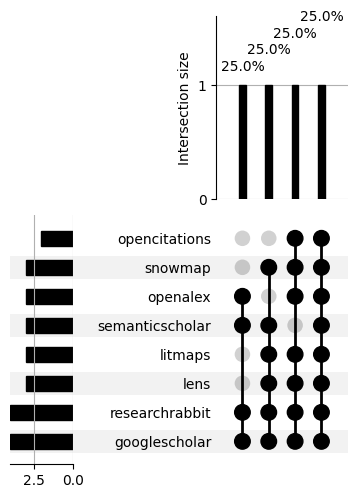

In [211]:
upset_from_global_presence(global_presence_slr2, "")

### **ARTIGO** **03**

In [ ]:
ROOT = Path("../data/csvs_slr03/seed_studies03")

gt_df_slr3, presence_by_seed_slr3, summary_slr3 = run_slr_seed_structure(
    root_path=ROOT,
    gt_filename="g-t_artigo03.csv",
    verbose=True,
    threshold=0.85 # Ensure consistency for seed structure processing
)

display(gt_df_slr3.head())
display(summary_slr3)
display(presence_by_seed_slr3["artigo01_03"])
display(presence_by_seed_slr3["artigo02_03"])
display(presence_by_seed_slr3["artigo03_03"])
display(presence_by_seed_slr3["artigo04_03"])
display(presence_by_seed_slr3["artigo05_03"])
#display(presence_by_seed_slr3["artigo06_03"]) foi retirado nos novos dados

artigo01_googleScholar.csv | tool=googlescholar | slr=seed_studies03 | before=29 | after_filter=8 | after_prepare=8
--- Processing GT Article (Normalized Title: practical experiences in designing and conducting empirical studies in industryacademia collaboration) with Tool: googlescholar (Seed: N/A)
Match found by DOI: 
  GT DOI: 10.1145/2593690.2593696 (Original: 10.1145/2593690.2593696)
  Tool DOI: 10.1145/2593690.2593696 (Original: 10.1145/2593690.2593696)
  Match Type: DOI

--- Processing GT Article (Normalized Title: the 41 view model of industryacademia collaboration) with Tool: googlescholar (Seed: N/A)
Match found by DOI: 
  GT DOI: 10.1145/2647648.2647651 (Original: 10.1145/2647648.2647651)
  Tool DOI: 10.1145/2647648.2647651 (Original: 10.1145/2647648.2647651)
  Match Type: DOI

--- Processing GT Article (Normalized Title: get the cogs in synchtime horizon aspects of industryacademia collaboration) with Tool: googlescholar (Seed: N/A)
Match found by DOI: 
  GT DOI: 10.1145/26

,Title,Doi,doi_norm,title_norm,uid
0,Practical experiences in designing and conduct...,10.1145/2593690.2593696,10.1145/2593690.2593696,practical experiences in designing and conduct...,10.1145/2593690.2593696
1,The 4+1 view model of industry-academia collab...,10.1145/2647648.2647651,10.1145/2647648.2647651,the 41 view model of industryacademia collabor...,10.1145/2647648.2647651
2,Get the cogs in synch-time horizon aspects of ...,10.1145/2647648.2647652,10.1145/2647648.2647652,get the cogs in synchtime horizon aspects of i...,10.1145/2647648.2647652
3,Empirical software engineering research with i...,10.1109/CESI.2013.6618469,10.1109/cesi.2013.6618469,empirical software engineering research with i...,10.1109/cesi.2013.6618469
4,Some researcher considerations when conducting...,10.1109/CESI.2013.6618476,10.1109/cesi.2013.6618476,some researcher considerations when conducting...,10.1109/cesi.2013.6618476


,folder,file,tool,gt_total,tool_total_raw,match_doi,match_title_only,match_total,seed
0,artigo01_03,artigo01_googleScholar.csv,googlescholar,22,8,3,2,5,artigo01_03
1,artigo01_03,artigo01_lens.csv,lens,22,9,5,0,5,artigo01_03
2,artigo01_03,artigo01_litmaps.csv,litmaps,22,9,5,0,5,artigo01_03
3,artigo01_03,artigo01_openAlex.csv,openalex,22,9,5,0,5,artigo01_03
4,artigo01_03,artigo01_opencitations.csv,opencitations,22,5,5,0,5,artigo01_03
5,artigo01_03,artigo01_researchRabbit.csv,researchrabbit,22,10,0,5,5,artigo01_03
6,artigo01_03,artigo01_semanticscholar.csv,semanticscholar,22,9,5,0,5,artigo01_03
7,artigo01_03,artigo01_snowmap.csv,snowmap,22,11,5,0,5,artigo01_03
8,artigo02_03,artigo02_googleScholar.csv,googlescholar,22,18,5,0,5,artigo02_03
9,artigo02_03,artigo02_lens.csv,lens,22,7,1,0,1,artigo02_03


,googlescholar,lens,litmaps,researchrabbit,semanticscholar,openalex,opencitations,snowmap
gt_record,,,,,,,,
10.1145/2593690.2593696,True,True,True,True,True,True,True,True
10.1145/2647648.2647651,True,True,True,True,True,True,True,True
10.1145/2647648.2647652,True,True,True,True,True,True,True,True
10.1109/cesi.2013.6618469,True,True,True,True,True,True,True,True
10.1109/cesi.2013.6618476,True,True,True,True,True,True,True,True
10.1145/2593690.2593694,False,False,False,False,False,False,False,False
10.1145/2593690.2593691,False,False,False,False,False,False,False,False
10.1109/cesi.2013.6618466,False,False,False,False,False,False,False,False
10.1145/2647648.2647654,False,False,False,False,False,False,False,False


,googlescholar,lens,litmaps,researchrabbit,semanticscholar,openalex,opencitations,snowmap
gt_record,,,,,,,,
10.1145/2593690.2593696,True,False,True,True,True,False,False,True
10.1145/2647648.2647651,True,False,True,True,True,False,False,True
10.1145/2647648.2647652,True,False,True,True,True,False,False,True
10.1109/cesi.2013.6618469,False,False,False,False,False,False,False,False
10.1109/cesi.2013.6618476,False,False,False,False,False,False,False,False
10.1145/2593690.2593694,True,True,True,True,True,True,True,True
10.1145/2593690.2593691,True,False,True,True,True,False,False,True
10.1109/cesi.2013.6618466,False,False,False,False,False,False,False,False
10.1145/2647648.2647654,False,False,False,False,False,False,False,False


,googlescholar,lens,litmaps,researchrabbit,semanticscholar,openalex,opencitations,snowmap
gt_record,,,,,,,,
10.1145/2593690.2593696,False,True,True,True,True,True,True,True
10.1145/2647648.2647651,False,False,False,False,False,False,False,False
10.1145/2647648.2647652,True,True,True,True,True,True,True,True
10.1109/cesi.2013.6618469,True,True,True,True,True,True,True,True
10.1109/cesi.2013.6618476,False,False,False,False,False,False,False,False
10.1145/2593690.2593694,False,True,True,True,True,True,True,True
10.1145/2593690.2593691,False,False,False,False,False,False,False,False
10.1109/cesi.2013.6618466,True,True,True,True,True,True,True,True
10.1145/2647648.2647654,True,True,True,True,True,True,True,True


,googlescholar,lens,litmaps,researchrabbit,semanticscholar,openalex,opencitations,snowmap
gt_record,,,,,,,,
10.1145/2593690.2593696,True,True,False,True,True,True,True,True
10.1145/2647648.2647651,True,True,False,True,True,True,True,True
10.1145/2647648.2647652,True,True,False,True,True,True,True,True
10.1109/cesi.2013.6618469,True,True,False,True,True,True,True,True
10.1109/cesi.2013.6618476,False,False,False,False,False,False,False,False
10.1145/2593690.2593694,False,False,False,False,False,False,False,False
10.1145/2593690.2593691,False,False,False,False,False,False,False,False
10.1109/cesi.2013.6618466,False,False,False,False,False,False,False,False
10.1145/2647648.2647654,False,False,False,False,False,False,False,False


,googlescholar,lens,litmaps,researchrabbit,semanticscholar,openalex,opencitations,snowmap
gt_record,,,,,,,,
10.1145/2593690.2593696,False,False,False,False,False,False,False,False
10.1145/2647648.2647651,False,False,False,False,False,False,False,False
10.1145/2647648.2647652,False,False,False,False,False,False,False,False
10.1109/cesi.2013.6618469,False,False,False,False,False,False,False,False
10.1109/cesi.2013.6618476,False,False,False,False,False,False,False,False
10.1145/2593690.2593694,False,False,False,False,False,False,False,False
10.1145/2593690.2593691,False,False,False,False,False,False,False,False
10.1109/cesi.2013.6618466,False,False,False,False,False,False,False,False
10.1145/2647648.2647654,False,False,False,False,False,False,False,False


In [ ]:
ROOT = Path("../data/csvs_slr03/seed_studies03")

gt_df_slr3, presence_by_seed_slr3, summary_slr3 = run_slr_seed_structure(
    root_path=ROOT,
    gt_filename='g-t_artigo03.csv',
    verbose=True,
    threshold=0.85
)

# Find the specific article in the gt_df_slr3 for debugging
article_original_title_slr3 = "Is action research the path to a solid research culture in IS/SE for Costa Rica?"
normalized_article_title = normalize_title(article_original_title_slr3)

print(f"\nLooking for GT article with normalized title: '{normalized_article_title}'")

# Check if the article is in the ground truth after normalization
gt_article_row = gt_df_slr3[gt_df_slr3['title_norm'] == normalized_article_title]

if not gt_article_row.empty:
    print(f"Found GT article: {gt_article_row['Title'].iloc[0]}")
    gt_uid = gt_article_row['uid'].iloc[0]
    print(f"GT UID: {gt_uid}")

    # Check presence in each seed's presence_df
    found_in_any_seed = False
    for seed_name, presence_df in presence_by_seed_slr3.items():
        if gt_uid in presence_df.index:
            if presence_df.loc[gt_uid].any(): # Check if it's found by any tool in this seed
                print(f"Article '{gt_uid}' found by at least one tool in seed '{seed_name}':")
                print(presence_df.loc[gt_uid])
                found_in_any_seed = True
            else:
                print(f"Article '{gt_uid}' not found by any tool in seed '{seed_name}'.")
        else:
            print(f"Article '{gt_uid}' not in presence_df for seed '{seed_name}'.")
    if not found_in_any_seed:
        print(f"Article '{gt_uid}' was not found by any tool in any seed for SLR3.")
else:
    print(f"Article '{article_original_title_slr3}' (normalized to '{normalized_article_title}') not found in the ground truth DataFrame for SLR3 after normalization.")

artigo01_googleScholar.csv | tool=googlescholar | slr=seed_studies03 | before=29 | after_filter=8 | after_prepare=8
--- Processing GT Article (Normalized Title: practical experiences in designing and conducting empirical studies in industryacademia collaboration) with Tool: googlescholar (Seed: N/A)
Match found by DOI: 
  GT DOI: 10.1145/2593690.2593696 (Original: 10.1145/2593690.2593696)
  Tool DOI: 10.1145/2593690.2593696 (Original: 10.1145/2593690.2593696)
  Match Type: DOI

--- Processing GT Article (Normalized Title: the 41 view model of industryacademia collaboration) with Tool: googlescholar (Seed: N/A)
Match found by DOI: 
  GT DOI: 10.1145/2647648.2647651 (Original: 10.1145/2647648.2647651)
  Tool DOI: 10.1145/2647648.2647651 (Original: 10.1145/2647648.2647651)
  Match Type: DOI

--- Processing GT Article (Normalized Title: get the cogs in synchtime horizon aspects of industryacademia collaboration) with Tool: googlescholar (Seed: N/A)
Match found by DOI: 
  GT DOI: 10.1145/26

In [214]:
print("\nInspecting gt_df_slr3 for variations of the article title...")

# The problematic article's title (original and normalized target)
article_original_title = "Is action research the path to a solid research culture in IS/SE for Costa Rica?"
expected_normalized_title = normalize_title(article_original_title)

# Filter gt_df_slr3 for rows that contain parts of the expected normalized title
# This is a broader search to catch any subtle differences
search_terms = expected_normalized_title.split()

found_potential_matches = gt_df_slr3[
    gt_df_slr3['title_norm'].apply(lambda x: any(term in x for term in search_terms))
]

if not found_potential_matches.empty:
    print(f"\nPotential matches found in gt_df_slr3 based on search terms derived from '{article_original_title}':")
    with pd.option_context('display.max_rows', None, 'display.max_columns', None, 'display.width', 1000):
        display(found_potential_matches[['Title', 'title_norm', 'doi_norm']])
else:
    print(f"\nNo potential matches found in gt_df_slr3 for title containing parts of '{article_original_title}'.")

# Also check if the exact normalized title exists (should confirm the previous output)
exact_match_in_gt = gt_df_slr3[gt_df_slr3['title_norm'] == expected_normalized_title]
if exact_match_in_gt.empty:
    print(f"\nConfirming: Exact normalized title '{expected_normalized_title}' not found in gt_df_slr3.")
else:
    print(f"\nFound exact match for normalized title '{expected_normalized_title}' in gt_df_slr3:")
    display(exact_match_in_gt[['Title', 'title_norm', 'doi_norm']])


# Now, let's look at the raw content of the CSV to be absolutely sure what's there
print("\nReading g-t_artigo03.csv directly and normalizing titles for inspection...")
raw_gt_df = pd.read_csv(ROOT / "g-t_artigo03.csv")
raw_gt_df.columns = [c.strip() for c in raw_gt_df.columns]

# Find the actual title column in the raw DataFrame
raw_title_col = find_title_column(raw_gt_df)

if raw_title_col:
    raw_gt_df['temp_title_norm'] = raw_gt_df[raw_title_col].apply(normalize_title)
    raw_gt_df['temp_doi_norm'] = raw_gt_df[find_doi_column(raw_gt_df)].apply(normalize_doi)

    print(f"\nLooking for original title '{article_original_title}' in raw_gt_df, and its normalized form:")
    found_in_raw = raw_gt_df[
        (raw_gt_df[raw_title_col].str.contains(article_original_title, case=False, na=False)) |
        (raw_gt_df['temp_title_norm'] == expected_normalized_title)
    ]

    if not found_in_raw.empty:
        with pd.option_context('display.max_rows', None, 'display.max_columns', None, 'display.width', 1000):
            display(found_in_raw[[raw_title_col, 'temp_title_norm', 'temp_doi_norm']])
    else:
        print(f"Original title '{article_original_title}' or its normalized form not found in the raw g-t_artigo03.csv after direct loading and normalization.")
else:
    print("Could not find a title column in the raw g-t_artigo03.csv.")


Inspecting gt_df_slr3 for variations of the article title...

Potential matches found in gt_df_slr3 based on search terms derived from 'Is action research the path to a solid research culture in IS/SE for Costa Rica?':


,Title,title_norm,doi_norm
0,Practical experiences in designing and conduct...,practical experiences in designing and conduct...,10.1145/2593690.2593696
1,The 4+1 view model of industry-academia collab...,the 41 view model of industryacademia collabor...,10.1145/2647648.2647651
2,Get the cogs in synch-time horizon aspects of ...,get the cogs in synchtime horizon aspects of i...,10.1145/2647648.2647652
3,Empirical software engineering research with i...,empirical software engineering research with i...,10.1109/cesi.2013.6618469
4,Some researcher considerations when conducting...,some researcher considerations when conducting...,10.1109/cesi.2013.6618476
5,Lessons learned on applying design science for...,lessons learned on applying design science for...,10.1145/2593690.2593694
6,Topic selection in industry experiments,topic selection in industry experiments,10.1145/2593690.2593691
7,Success factors for empirical studies in indus...,success factors for empirical studies in indus...,10.1109/cesi.2013.6618466
8,Foundations for long-term collaborative research,foundations for longterm collaborative research,10.1145/2647648.2647654
9,Finding relevant research solutions for practi...,finding relevant research solutions for practi...,10.1145/2647648.264765



Found exact match for normalized title 'is action research the path to a solid research culture in is/se for costa rica?' in gt_df_slr3:


,Title,title_norm,doi_norm
13,Is action research the path to a solid researc...,is action research the path to a solid researc...,None



Reading g-t_artigo03.csv directly and normalizing titles for inspection...

Looking for original title 'Is action research the path to a solid research culture in IS/SE for Costa Rica?' in raw_gt_df, and its normalized form:


,Title,temp_title_norm,temp_doi_norm
13,Is action research the path to a solid researc...,is action research the path to a solid researc...,None


In [ ]:
def compute_global_recall(presence_by_seed, gt_size):
    # junta todos os seeds
    all_presence = pd.concat(presence_by_seed.values())

    # agrupa por artigo (remove duplicação entre seeds)
    agg = all_presence.groupby(level=0).max()

    # calcula recall em %
    recall = (
        agg.sum() / gt_size
    ) * 100

    # organiza, arredonda e formata
    recall = (
        recall.sort_values(ascending=False)
        .round(1)  # 👈 aqui resolve as casas decimais
        .reset_index(name="Included (%)")
    )

    return recall

ROOT = Path("../data/csvs_slr03/seed_studies03")

gt_df_slr3, presence_by_seed_slr3, summary_slr3 = run_slr_seed_structure(
    root_path=ROOT,
    gt_filename="g-t_artigo03.csv",
    verbose=True,
    threshold=0.85 # Ensure consistency for seed structure processing
)

gt_size = len(gt_df_slr3)

global_recall = compute_global_recall(presence_by_seed_slr3, gt_size)
display(global_recall)

artigo01_googleScholar.csv | tool=googlescholar | slr=seed_studies03 | before=29 | after_filter=8 | after_prepare=8
--- Processing GT Article (Normalized Title: practical experiences in designing and conducting empirical studies in industryacademia collaboration) with Tool: googlescholar (Seed: N/A)
Match found by DOI: 
  GT DOI: 10.1145/2593690.2593696 (Original: 10.1145/2593690.2593696)
  Tool DOI: 10.1145/2593690.2593696 (Original: 10.1145/2593690.2593696)
  Match Type: DOI

--- Processing GT Article (Normalized Title: the 41 view model of industryacademia collaboration) with Tool: googlescholar (Seed: N/A)
Match found by DOI: 
  GT DOI: 10.1145/2647648.2647651 (Original: 10.1145/2647648.2647651)
  Tool DOI: 10.1145/2647648.2647651 (Original: 10.1145/2647648.2647651)
  Match Type: DOI

--- Processing GT Article (Normalized Title: get the cogs in synchtime horizon aspects of industryacademia collaboration) with Tool: googlescholar (Seed: N/A)
Match found by DOI: 
  GT DOI: 10.1145/26

,index,Included (%)
0,googlescholar,95.5
1,snowmap,90.9
2,semanticscholar,86.4
3,litmaps,81.8
4,openalex,81.8
5,researchrabbit,81.8
6,lens,77.3
7,opencitations,63.6


In [216]:
global_presence_slr3 = None

for seed, df in presence_by_seed_slr3.items():
    df_bin = df[ALL_TOOLS].astype(bool)
    global_presence_slr3 = df_bin.copy() if global_presence_slr3 is None else (global_presence_slr3 | df_bin)

global_presence_slr3 = global_presence_slr3.astype(int)
display(global_presence_slr3)

,googlescholar,lens,litmaps,researchrabbit,semanticscholar,openalex,opencitations,snowmap
gt_record,,,,,,,,
10.1145/2593690.2593696,1,1,1,1,1,1,1,1
10.1145/2647648.2647651,1,1,1,1,1,1,1,1
10.1145/2647648.2647652,1,1,1,1,1,1,1,1
10.1109/cesi.2013.6618469,1,1,1,1,1,1,1,1
10.1109/cesi.2013.6618476,1,1,1,1,1,1,1,1
10.1145/2593690.2593694,1,1,1,1,1,1,1,1
10.1145/2593690.2593691,1,0,1,1,1,0,0,1
10.1109/cesi.2013.6618466,1,1,1,1,1,1,1,1
10.1145/2647648.2647654,1,1,1,1,1,1,1,1


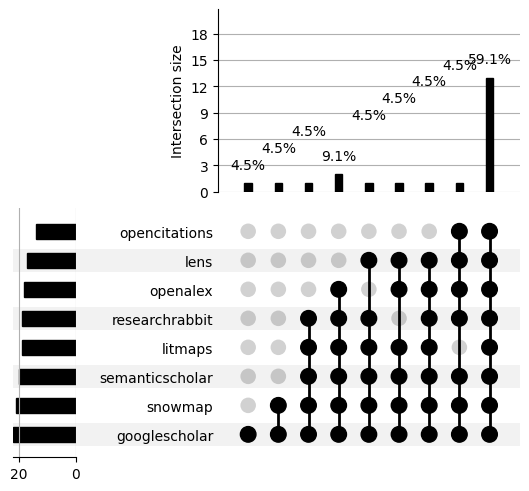

In [217]:
upset_from_global_presence(global_presence_slr3, "")

### **ARTIGO 04**

In [ ]:
ROOT = Path("../data/csvs_slr04/seed_studies04")

gt_df_slr4, presence_by_seed_slr4, summary_slr4 = run_slr_seed_structure(
    root_path=ROOT,
    gt_filename="g-t_artigo04.csv",
    verbose=True,
    threshold=0.85 # Ensure consistency for seed structure processing
)

display(gt_df_slr4)
display(summary_slr4)
display(presence_by_seed_slr4["artigo01_04"])
display(presence_by_seed_slr4["artigo02_04"])
display(presence_by_seed_slr4["artigo03_04"])
display(presence_by_seed_slr4["artigo05_04"])
display(presence_by_seed_slr4["artigo06_04"])
display(presence_by_seed_slr4["artigo07_04"])
display("8:")
display(presence_by_seed_slr4["artigo08_04"])
display(presence_by_seed_slr4["artigo09_04"])
display(presence_by_seed_slr4["artigo11_04"])
display(presence_by_seed_slr4["artigo12_04"])
display(presence_by_seed_slr4["artigo13_04"])
display(presence_by_seed_slr4["artigo14_04"])
display(presence_by_seed_slr4["artigo15_04"])

googleScholar01_04.csv | tool=googlescholar | slr=seed_studies04 | before=32 | after_filter=32 | after_prepare=32
artigo01_04 | googleScholar01_04.csv | tool=googlescholar | doi_csv=0 | title_csv=32 | match_doi=0 | match_title_only=0 | total=0
lens01_04.csv | tool=lens | slr=seed_studies04 | before=14 | after_filter=14 | after_prepare=14
artigo01_04 | lens01_04.csv | tool=lens | doi_csv=14 | title_csv=14 | match_doi=0 | match_title_only=0 | total=0
litmap01_04.csv | tool=litmaps | slr=seed_studies04 | before=19 | after_filter=19 | after_prepare=19
artigo01_04 | litmap01_04.csv | tool=litmaps | doi_csv=18 | title_csv=19 | match_doi=0 | match_title_only=0 | total=0
openAlex01_04.csv | tool=openalex | slr=seed_studies04 | before=16 | after_filter=16 | after_prepare=16
artigo01_04 | openAlex01_04.csv | tool=openalex | doi_csv=16 | title_csv=16 | match_doi=0 | match_title_only=0 | total=0
openCitations01_04.csv | tool=opencitations | slr=seed_studies04 | before=14 | after_filter=14 | after_

,Title,Doi,doi_norm,title_norm,uid
0,The learning effect on organizational performa...,10.1108/EJMBE-03-2021-0107,10.1108/ejmbe-03-2021-0107,the learning effect on organizational performa...,10.1108/ejmbe-03-2021-0107
1,Towards an effective approach for architectura...,10.1504/IJGUC.2020.110908,10.1504/ijguc.2020.110908,towards an effective approach for architectura...,10.1504/ijguc.2020.110908
2,Socio-Technical Challenges Inhibiting Effectiv...,NaN,None,sociotechnical challenges inhibiting effective...,sociotechnical challenges inhibiting effective...
3,Influencing factors on knowledge sharing in vi...,10.3233/WOR-2112,10.3233/wor-2112,influencing factors on knowledge sharing in vi...,10.3233/wor-2112
4,Perceptions of knowledge management in Brazili...,10.5753/cibse.2022.20975,10.5753/cibse.2022.20975,perceptions of knowledge management in brazili...,10.5753/cibse.2022.20975
5,Implementing Knowledge Management in an IT Sta...,10.1007/978-3-030-85990-9_59,10.1007/978-3-030-85990-9_59,implementing knowledge management in an it sta...,10.1007/978-3-030-85990-9_59
6,Ontology Learning for Systems Engineering Body...,10.1109/TII.2020.2990953,10.1109/tii.2020.2990953,ontology learning for systems engineering body...,10.1109/tii.2020.2990953
7,The role of knowledge-based resources in Agile...,10.1016/j.jss.2022.111572,10.1016/j.jss.2022.111572,the role of knowledgebased resources in agile ...,10.1016/j.jss.2022.111572
8,Development of an Ontology-based Approach for ...,10.5753/jserd.2021.1898,10.5753/jserd.2021.1898,development of an ontologybased approach for k...,10.5753/jserd.2021.1898


,folder,file,tool,gt_total,tool_total_raw,match_doi,match_title_only,match_total,seed
0,artigo01_04,googleScholar01_04.csv,googlescholar,9,32,0,0,0,artigo01_04
1,artigo01_04,lens01_04.csv,lens,9,14,0,0,0,artigo01_04
2,artigo01_04,litmap01_04.csv,litmaps,9,19,0,0,0,artigo01_04
3,artigo01_04,openAlex01_04.csv,openalex,9,16,0,0,0,artigo01_04
4,artigo01_04,openCitations01_04.csv,opencitations,9,14,0,0,0,artigo01_04
...,...,...,...,...,...,...,...,...,...
97,artigo15_04,openAlex15_04.csv,openalex,9,8,0,0,0,artigo15_04
98,artigo15_04,openCitations15_04.csv,opencitations,9,6,0,0,0,artigo15_04
99,artigo15_04,our_tool15_04.csv,snowmap,9,10,0,0,0,artigo15_04
100,artigo15_04,researchRabbit15_04.csv,researchrabbit,9,10,0,0,0,artigo15_04


,googlescholar,lens,litmaps,researchrabbit,semanticscholar,openalex,opencitations,snowmap
gt_record,,,,,,,,
10.1108/ejmbe-03-2021-0107,False,False,False,False,False,False,False,False
10.1504/ijguc.2020.110908,False,False,False,False,False,False,False,False
sociotechnical challenges inhibiting effective knowledge sharing among ict workers in underresourced egovernment project teams,False,False,False,False,False,False,False,False
10.3233/wor-2112,False,False,False,False,False,False,False,False
10.5753/cibse.2022.20975,False,False,False,False,False,False,False,False
10.1007/978-3-030-85990-9_59,False,False,False,False,False,False,False,False
10.1109/tii.2020.2990953,False,False,False,False,False,False,False,False
10.1016/j.jss.2022.111572,False,False,False,False,False,False,False,False
10.5753/jserd.2021.1898,False,False,False,False,False,False,False,False


,googlescholar,lens,litmaps,researchrabbit,semanticscholar,openalex,opencitations,snowmap
gt_record,,,,,,,,
10.1108/ejmbe-03-2021-0107,True,False,True,True,True,True,False,True
10.1504/ijguc.2020.110908,True,False,False,False,False,False,False,False
sociotechnical challenges inhibiting effective knowledge sharing among ict workers in underresourced egovernment project teams,True,False,False,False,False,False,False,False
10.3233/wor-2112,True,True,True,True,True,True,False,True
10.5753/cibse.2022.20975,False,False,False,False,False,False,False,False
10.1007/978-3-030-85990-9_59,False,False,False,False,False,False,False,False
10.1109/tii.2020.2990953,False,False,False,False,False,False,False,False
10.1016/j.jss.2022.111572,False,False,False,False,False,False,False,False
10.5753/jserd.2021.1898,False,False,False,False,False,False,False,False


...

,googlescholar,lens,litmaps,researchrabbit,semanticscholar,openalex,opencitations,snowmap
gt_record,,,,,,,,
10.1108/ejmbe-03-2021-0107,False,False,False,False,False,False,False,False
10.1504/ijguc.2020.110908,False,False,False,False,False,False,False,False
sociotechnical challenges inhibiting effective knowledge sharing among ict workers in underresourced egovernment project teams,False,False,False,False,False,False,False,False
10.3233/wor-2112,False,False,False,False,False,False,False,False
10.5753/cibse.2022.20975,False,False,False,False,False,False,False,False
10.1007/978-3-030-85990-9_59,False,False,False,False,False,False,False,False
10.1109/tii.2020.2990953,False,False,False,False,False,False,False,False
10.1016/j.jss.2022.111572,False,False,False,False,False,False,False,False
10.5753/jserd.2021.1898,False,False,False,False,False,False,False,False


,googlescholar,lens,litmaps,researchrabbit,semanticscholar,openalex,opencitations,snowmap
gt_record,,,,,,,,
10.1108/ejmbe-03-2021-0107,False,False,False,False,False,False,False,False
10.1504/ijguc.2020.110908,False,False,False,False,False,False,False,False
sociotechnical challenges inhibiting effective knowledge sharing among ict workers in underresourced egovernment project teams,False,False,False,False,False,False,False,False
10.3233/wor-2112,False,False,False,False,False,False,False,False
10.5753/cibse.2022.20975,False,False,False,False,False,False,False,False
10.1007/978-3-030-85990-9_59,False,False,False,False,False,False,False,False
10.1109/tii.2020.2990953,False,False,False,False,False,False,False,False
10.1016/j.jss.2022.111572,True,True,True,True,True,True,True,True
10.5753/jserd.2021.1898,False,False,False,False,False,False,False,False


,googlescholar,lens,litmaps,researchrabbit,semanticscholar,openalex,opencitations,snowmap
gt_record,,,,,,,,
10.1108/ejmbe-03-2021-0107,False,False,False,False,False,False,False,False
10.1504/ijguc.2020.110908,False,False,False,False,False,False,False,False
sociotechnical challenges inhibiting effective knowledge sharing among ict workers in underresourced egovernment project teams,False,False,False,False,False,False,False,False
10.3233/wor-2112,False,False,False,False,False,False,False,False
10.5753/cibse.2022.20975,False,False,False,False,False,False,False,False
10.1007/978-3-030-85990-9_59,False,False,False,False,False,False,False,False
10.1109/tii.2020.2990953,False,False,False,False,False,False,False,False
10.1016/j.jss.2022.111572,False,False,False,False,False,False,False,False
10.5753/jserd.2021.1898,False,False,False,False,False,False,False,False


,googlescholar,lens,litmaps,researchrabbit,semanticscholar,openalex,opencitations,snowmap
gt_record,,,,,,,,
10.1108/ejmbe-03-2021-0107,False,False,False,False,False,False,False,False
10.1504/ijguc.2020.110908,False,False,False,False,False,False,False,False
sociotechnical challenges inhibiting effective knowledge sharing among ict workers in underresourced egovernment project teams,False,False,False,False,False,False,False,False
10.3233/wor-2112,False,False,False,False,False,False,False,False
10.5753/cibse.2022.20975,False,False,False,False,False,False,False,False
10.1007/978-3-030-85990-9_59,False,False,False,False,False,False,False,False
10.1109/tii.2020.2990953,False,False,False,False,False,False,False,False
10.1016/j.jss.2022.111572,False,False,False,False,False,False,False,False
10.5753/jserd.2021.1898,False,False,False,False,False,False,False,False


,googlescholar,lens,litmaps,researchrabbit,semanticscholar,openalex,opencitations,snowmap
gt_record,,,,,,,,
10.1108/ejmbe-03-2021-0107,False,False,False,False,False,False,False,False
10.1504/ijguc.2020.110908,False,False,False,False,False,False,False,False
sociotechnical challenges inhibiting effective knowledge sharing among ict workers in underresourced egovernment project teams,False,False,False,False,False,False,False,False
10.3233/wor-2112,False,False,False,False,False,False,False,False
10.5753/cibse.2022.20975,False,False,False,False,False,False,False,False
10.1007/978-3-030-85990-9_59,False,False,False,False,False,False,False,False
10.1109/tii.2020.2990953,True,False,False,False,False,False,False,False
10.1016/j.jss.2022.111572,False,False,False,False,False,False,False,False
10.5753/jserd.2021.1898,False,False,False,False,False,False,False,False


In [ ]:
def compute_global_recall(presence_by_seed, gt_size):
    # junta todos os seeds
    all_presence = pd.concat(presence_by_seed.values())

    # agrupa por artigo (remove duplicação entre seeds)
    agg = all_presence.groupby(level=0).max()

    # calcula recall em %
    recall = (
        agg.sum() / gt_size
    ) * 100

    # organiza, arredonda e formata
    recall = (
        recall.sort_values(ascending=False)
        .round(1)  # 👈 aqui resolve as casas decimais
        .reset_index(name="Included (%)")
    )

    return recall

ROOT = Path("../data/csvs_slr04/seed_studies04")

gt_df_slr4, presence_by_seed_slr4, summary_slr4 = run_slr_seed_structure(
    root_path=ROOT,
    gt_filename="g-t_artigo04.csv",
    verbose=True,
    threshold=0.85 # Ensure consistency for seed structure processing
)

gt_size = len(gt_df_slr4)

global_recall = compute_global_recall(presence_by_seed_slr4, gt_size)
display(global_recall)

googleScholar01_04.csv | tool=googlescholar | slr=seed_studies04 | before=32 | after_filter=32 | after_prepare=32
artigo01_04 | googleScholar01_04.csv | tool=googlescholar | doi_csv=0 | title_csv=32 | match_doi=0 | match_title_only=0 | total=0
lens01_04.csv | tool=lens | slr=seed_studies04 | before=14 | after_filter=14 | after_prepare=14
artigo01_04 | lens01_04.csv | tool=lens | doi_csv=14 | title_csv=14 | match_doi=0 | match_title_only=0 | total=0
litmap01_04.csv | tool=litmaps | slr=seed_studies04 | before=19 | after_filter=19 | after_prepare=19
artigo01_04 | litmap01_04.csv | tool=litmaps | doi_csv=18 | title_csv=19 | match_doi=0 | match_title_only=0 | total=0
openAlex01_04.csv | tool=openalex | slr=seed_studies04 | before=16 | after_filter=16 | after_prepare=16
artigo01_04 | openAlex01_04.csv | tool=openalex | doi_csv=16 | title_csv=16 | match_doi=0 | match_title_only=0 | total=0
openCitations01_04.csv | tool=opencitations | slr=seed_studies04 | before=14 | after_filter=14 | after_

,index,Included (%)
0,googlescholar,100.0
1,litmaps,66.7
2,researchrabbit,66.7
3,openalex,66.7
4,snowmap,55.6
5,semanticscholar,55.6
6,lens,44.4
7,opencitations,22.2


In [220]:
global_presence_slr4 = None

for seed, df in presence_by_seed_slr4.items():
    df_bin = df[ALL_TOOLS].astype(bool)
    global_presence_slr4 = df_bin.copy() if global_presence_slr4 is None else (global_presence_slr4 | df_bin)

global_presence_slr4 = global_presence_slr4.astype(int)
display(global_presence_slr4)

,googlescholar,lens,litmaps,researchrabbit,semanticscholar,openalex,opencitations,snowmap
gt_record,,,,,,,,
10.1108/ejmbe-03-2021-0107,1,0,1,1,1,1,0,1
10.1504/ijguc.2020.110908,1,0,0,0,0,0,0,0
sociotechnical challenges inhibiting effective knowledge sharing among ict workers in underresourced egovernment project teams,1,0,0,0,0,0,0,0
10.3233/wor-2112,1,1,1,1,1,1,0,1
10.5753/cibse.2022.20975,1,0,1,1,1,1,0,1
10.1007/978-3-030-85990-9_59,1,1,1,1,0,1,1,0
10.1109/tii.2020.2990953,1,0,0,0,0,0,0,0
10.1016/j.jss.2022.111572,1,1,1,1,1,1,1,1
10.5753/jserd.2021.1898,1,1,1,1,1,1,0,1


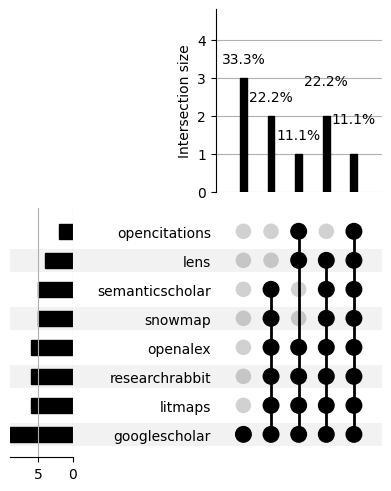

In [221]:

upset_from_global_presence(global_presence_slr4, "")

### **ARTIGO 01**

In [ ]:
ROOT = Path("../data/csvs_slr01")

gt_df_slr1, presence_slr1, summary_slr1 = run_slr01(
    root_path=ROOT,
    gt_filename="g-t_artigo01.csv",
    verbose=True,
    threshold=0.85 # Using the same threshold as compute_metrics
)

display(gt_df_slr1)
display(summary_slr1)
display(presence_slr1)

artigo01_googleScholar.csv | tool=googlescholar | slr=new_csvs_slr01 | before=135 | after_filter=135 | after_prepare=135
--- Processing GT Article (Normalized Title: outofthebox prediction of nonfunctional variant properties using automated machine learning) with Tool: googlescholar (Seed: N/A)
Match found by DOI: 
  GT DOI: 10.1145/3646548.3676546 (Original: 10.1145/3646548.3676546)
  Tool DOI: 10.1145/3646548.3676546 (Original: 10.1145/3646548.3676546)
  Match Type: DOI

--- Processing GT Article (Normalized Title: enhanced optimization space learning towards realtime compiler optimization) with Tool: googlescholar (Seed: N/A)
Match found by DOI: 
  GT DOI: 10.1007/978-981-96-8889-0_7 (Original: 10.1007/978-981-96-8889-0_7)
  Tool DOI: 10.1007/978-981-96-8889-0_7 (Original: 10.1007/978-981-96-8889-0_7)
  Match Type: DOI

--- Processing GT Article (Normalized Title: automated learning of software configuration spaces is not easy) with Tool: googlescholar (Seed: N/A)
Match found by DOI

,Title,Doi,doi_norm,title_norm,uid
0,Out-of-the-Box Prediction of Non-Functional Va...,10.1145/3646548.3676546,10.1145/3646548.3676546,outofthebox prediction of nonfunctional varian...,10.1145/3646548.3676546
1,Enhanced Optimization Space Learning: Towards ...,10.1007/978-981-96-8889-0_7,10.1007/978-981-96-8889-0_7,enhanced optimization space learning towards r...,10.1007/978-981-96-8889-0_7
2,Unveiling the Impact of Sampling on Feature Se...,10.1109/ICSR66718.2025.00012,10.1109/icsr66718.2025.00012,unveiling the impact of sampling on feature se...,10.1109/icsr66718.2025.00012
3,Automated Learning of Software Configuration S...,10.1145/3744915.3748458,10.1145/3744915.3748458,automated learning of software configuration s...,10.1145/3744915.3748458
4,In the Search for Truth: Navigating Variabilit...,10.1145/3744915.3748470,10.1145/3744915.3748470,in the search for truth navigating variability...,10.1145/3744915.3748470
5,Prompting for performance: Exploring llms for ...,10.1109/ICTAI66417.2025.00023,10.1109/ictai66417.2025.00023,prompting for performance exploring llms for c...,10.1109/ictai66417.2025.00023
6,CSAT: Configuration structure-aware tuning for...,10.1016/j.jss.2024.112316,10.1016/j.jss.2024.112316,csat configuration structureaware tuning for h...,10.1016/j.jss.2024.112316
7,Applying Graph Neural Networks to Learn Graph ...,10.1145/3715340.3715444,10.1145/3715340.3715444,applying graph neural networks to learn graph ...,10.1145/3715340.3715444
8,Understanding Product Line Runtime Performance...,10.1145/3744915.3748472,10.1145/3744915.3748472,understanding product line runtime performance...,10.1145/3744915.3748472
9,Feature Modelling,10.1007/978-3-031-61874-1_2,10.1007/978-3-031-61874-1_2,feature modelling,10.1007/978-3-031-61874-1_2


,folder,file,tool,gt_total,tool_total_raw,match_doi,match_title_only,match_total
0,new_csvs_slr01,artigo01_googleScholar.csv,googlescholar,40,135,25,15,40
1,new_csvs_slr01,artigo01_lens.csv,lens,40,93,26,0,26
2,new_csvs_slr01,artigo01_litmaps.csv,litmaps,40,156,37,1,38
3,new_csvs_slr01,artigo01_openAlex.csv,openalex,40,19,3,1,4
4,new_csvs_slr01,artigo01_opencitations.csv,opencitations,40,53,23,0,23
5,new_csvs_slr01,artigo01_researchRabbit.csv,researchrabbit,40,156,0,38,38
6,new_csvs_slr01,artigo01_semanticscholar.csv,semanticscholar,40,114,34,1,35
7,new_csvs_slr01,artigo01_snowmap.csv,snowmap,40,147,39,1,40


,googlescholar,lens,litmaps,researchrabbit,semanticscholar,openalex,opencitations,snowmap
gt_record,,,,,,,,
10.1145/3646548.3676546,True,True,True,True,True,False,True,True
10.1007/978-981-96-8889-0_7,True,True,True,True,False,False,True,True
10.1109/icsr66718.2025.00012,True,True,True,True,True,False,True,True
10.1145/3744915.3748458,True,True,True,True,True,False,True,True
10.1145/3744915.3748470,True,True,True,True,True,False,True,True
10.1109/ictai66417.2025.00023,True,True,True,True,True,False,False,True
10.1016/j.jss.2024.112316,True,True,True,True,True,False,True,True
10.1145/3715340.3715444,True,True,True,True,True,False,True,True
10.1145/3744915.3748472,True,True,True,True,True,False,True,True


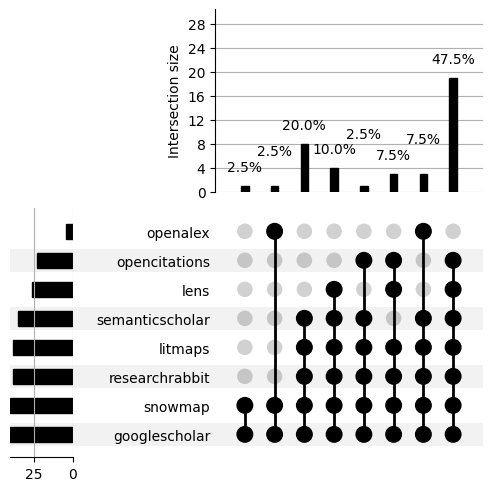

In [223]:
upset_from_global_presence(presence_slr1, "")

In [ ]:
from pathlib import Path
import pandas as pd

def compute_recall_slr1(presence_df, gt_size):
    df = presence_df.astype(bool)

    recall = (df.sum() / gt_size) * 100

    recall = (
        recall.sort_values(ascending=False)
        .round(1)
        .reset_index(name="Included (%)")
    )

    return recall

ROOT = Path("../data/csvs_slr01")


gt_df_slr1, presence_slr1, summary_slr1 = run_slr01(
    root_path=ROOT,
    gt_filename="g-t_artigo01.csv",
    verbose=True,
    threshold=0.85 # Ensure consistency for recall calculation here as well
)

gt_size = len(gt_df_slr1)

recall_slr1 = compute_recall_slr1(presence_slr1, gt_size)

display(recall_slr1)

artigo01_googleScholar.csv | tool=googlescholar | slr=new_csvs_slr01 | before=135 | after_filter=135 | after_prepare=135
--- Processing GT Article (Normalized Title: outofthebox prediction of nonfunctional variant properties using automated machine learning) with Tool: googlescholar (Seed: N/A)
Match found by DOI: 
  GT DOI: 10.1145/3646548.3676546 (Original: 10.1145/3646548.3676546)
  Tool DOI: 10.1145/3646548.3676546 (Original: 10.1145/3646548.3676546)
  Match Type: DOI

--- Processing GT Article (Normalized Title: enhanced optimization space learning towards realtime compiler optimization) with Tool: googlescholar (Seed: N/A)
Match found by DOI: 
  GT DOI: 10.1007/978-981-96-8889-0_7 (Original: 10.1007/978-981-96-8889-0_7)
  Tool DOI: 10.1007/978-981-96-8889-0_7 (Original: 10.1007/978-981-96-8889-0_7)
  Match Type: DOI

--- Processing GT Article (Normalized Title: automated learning of software configuration spaces is not easy) with Tool: googlescholar (Seed: N/A)
Match found by DOI

,index,Included (%)
0,googlescholar,100.0
1,snowmap,100.0
2,researchrabbit,95.0
3,litmaps,95.0
4,semanticscholar,87.5
5,lens,65.0
6,opencitations,57.5
7,openalex,10.0


computar as métricas

In [225]:
def compute_metrics(
    gt_df: pd.DataFrame,
    tool_df: pd.DataFrame,
    threshold: float = 0.85,
    tool_name: Optional[str] = None,
    verbose_output: bool = False
) -> dict:
    gt = prepare_matching_dataframe(gt_df, tool=None)

    # The tool_df is now expected to be already prepared (year filtered, normalized columns)
    # from the calling function (e.g., run_slr02_with_duplicates)
    tool = tool_df.copy()

    match_df, matched_tool_uids = match_gt_against_tool(
        gt,
        tool,
        threshold=threshold,
        tool_name=tool_name,
        verbose_output=verbose_output # Pass verbose_output here
    )

    tp = int(match_df["found"].sum())
    fn = len(gt) - tp

    tool_uid_set = set(tool["uid"].dropna())
    fp = len(tool_uid_set - matched_tool_uids)

    precision = tp / (tp + fp) if (tp + fp) else 0.0
    recall = tp / (tp + fn) if (tp + fn) else 0.0
    f1 = 2 * precision * recall / (precision + recall) if (precision + recall) else 0.0

    return {
        "tp": tp,
        "fp": fp,
        "fn": fn,
        "precision": precision,
        "recall": recall,
        "f1": f1,
        "gt_size": len(gt),
        "tool_unique_size": len(tool_uid_set),
        "doi_matches": int(match_df["match_doi"].sum()),
        "title_matches": int(match_df["match_title"].sum()),
    }


In [ ]:
from pathlib import Path
import pandas as pd

ROOT = Path("../data/csvs_slr01")


gt_df_slr1, presence_slr1, summary_slr1 = run_slr01(
    root_path=ROOT,
    gt_filename="g-t_artigo01.csv",
    verbose=True
)

slr = ROOT.name
gt = gt_df_slr1

linhas = []

for csv_path in sorted(ROOT.glob("*.csv")):
    if csv_path.name == "g-t_artigo01.csv":
        continue

    ferramenta = detect_tool_from_filename(csv_path)

    if ferramenta is None:
        #print(f"Ferramenta não reconhecida para arquivo: {csv_path.name}")
        continue

    df_tool_raw = pd.read_csv(csv_path)
    # Prepare the tool DataFrame before passing it to compute_metrics
    df_tool_prepared = prepare_matching_dataframe(df_tool_raw, tool=ferramenta)

    m = compute_metrics(
        gt_df=gt,
        tool_df=df_tool_prepared, # Pass the prepared DataFrame here
        threshold=0.85,
        tool_name=ferramenta
    )
    linhas.append({
    "SLR": slr,
    "Ferramenta": ferramenta,
    "TP": m["tp"],
    "FP": m["fp"],
    "FN": m["fn"],
    "Recall": round(m["recall"], 3),
    "Included (%)": round(m["recall"] * 100, 1),
    "Precision (%)": round(m["precision"] * 100, 1),
    "F1 (%)": round(m["f1"] * 100, 1),
})


tabela = pd.DataFrame(linhas).sort_values(
    ["Included (%)"],#"F1", , "Precision"
    ascending=False
).reset_index(drop=True)

tabela

artigo01_googleScholar.csv | tool=googlescholar | slr=new_csvs_slr01 | before=135 | after_filter=135 | after_prepare=135
--- Processing GT Article (Normalized Title: outofthebox prediction of nonfunctional variant properties using automated machine learning) with Tool: googlescholar (Seed: N/A)
Match found by DOI: 
  GT DOI: 10.1145/3646548.3676546 (Original: 10.1145/3646548.3676546)
  Tool DOI: 10.1145/3646548.3676546 (Original: 10.1145/3646548.3676546)
  Match Type: DOI

--- Processing GT Article (Normalized Title: enhanced optimization space learning towards realtime compiler optimization) with Tool: googlescholar (Seed: N/A)
Match found by DOI: 
  GT DOI: 10.1007/978-981-96-8889-0_7 (Original: 10.1007/978-981-96-8889-0_7)
  Tool DOI: 10.1007/978-981-96-8889-0_7 (Original: 10.1007/978-981-96-8889-0_7)
  Match Type: DOI

--- Processing GT Article (Normalized Title: automated learning of software configuration spaces is not easy) with Tool: googlescholar (Seed: N/A)
Match found by DOI

,SLR,Ferramenta,TP,FP,FN,Recall,Included (%),Precision (%),F1 (%)
0,new_csvs_slr01,googlescholar,40,92,0,1.000,100.0,30.3,46.5
1,new_csvs_slr01,snowmap,40,106,0,1.000,100.0,27.4,43.0
2,new_csvs_slr01,researchrabbit,38,102,2,0.950,95.0,27.1,42.2
3,new_csvs_slr01,litmaps,38,111,2,0.950,95.0,25.5,40.2
4,new_csvs_slr01,semanticscholar,35,64,5,0.875,87.5,35.4,50.4
5,new_csvs_slr01,lens,26,67,14,0.650,65.0,28.0,39.1
6,new_csvs_slr01,opencitations,23,30,17,0.575,57.5,43.4,49.5
7,new_csvs_slr01,openalex,4,15,36,0.100,10.0,21.1,13.6


In [227]:
from pathlib import Path
import pandas as pd
from collections import defaultdict

def run_slr02_with_duplicates(
    root_path: Path,
    gt_df_for_metrics: pd.DataFrame,
    threshold: float = 0.85
) -> pd.DataFrame:
    """
    Avaliação SLR2 SEM remover duplicatas.
    Mantém todos os artigos mesmo se aparecerem múltiplas vezes.
    """

    slr = root_path.parent.name
    linhas = []

    # 1. Agrupar resultados por ferramenta (mantendo o DataFrame original)
    tool_dfs = defaultdict(list)

    for seed_dir in sorted(root_path.iterdir()):
        if seed_dir.is_dir() and seed_dir.name.lower().startswith("artigo"):

            for csv_path in sorted(seed_dir.glob("*.csv")):

                ferramenta = detect_tool_from_filename(csv_path)
                if ferramenta is None:
                    continue

                # Get SLR name for year filtering (from the grand-parent or parent, same logic as resolve_slr_name)
                slr_name_for_year_filter = resolve_slr_name(csv_path)

                df_tool_raw = pd.read_csv(csv_path)

                # Apply year filtering before preparing the dataframe, for consistency
                df_tool_filtered = filter_by_year_rules(df_tool_raw, slr=slr_name_for_year_filter, tool=ferramenta)

                # Prepare for matching
                df_tool_prepared = prepare_matching_dataframe(df_tool_filtered, tool=ferramenta)

                # Add seed origin information
                if not df_tool_prepared.empty:
                    df_tool_prepared['_seed_origin'] = seed_dir.name

                tool_dfs[ferramenta].append(df_tool_prepared)

    # 2. Consolidar (sem remover duplicatas)
    # We need to ensure 'uid' and '_seed_origin' are present for empty DataFrames to avoid errors during concat
    expected_tool_cols = list(gt_df_for_metrics.columns) + ['doi_norm', 'title_norm', 'uid', '_seed_origin']
    tool_consolidated = {
        ferramenta: pd.concat(dfs, ignore_index=True) if dfs else pd.DataFrame(columns=expected_tool_cols)
        for ferramenta, dfs in tool_dfs.items()
    }

    # 3. Calcular métricas
    for ferramenta, df_tool_consolidated in tool_consolidated.items():
        # Pass already prepared and filtered df_tool_consolidated to compute_metrics
        # compute_metrics will then not need to call prepare_matching_dataframe on tool_df again
        m = compute_metrics(
            gt_df=gt_df_for_metrics,
            tool_df=df_tool_consolidated.copy(), # Pass a copy to avoid in-place modification issues if compute_metrics changes it
            threshold=threshold,
            tool_name=ferramenta
        )

        linhas.append({
            "SLR": slr,
            "Ferramenta": ferramenta,
            "Included (%)": round(m["recall"] * 100, 1),
            "TP": m["tp"],
            "FP": m["fp"],
            "FN": m["fn"],
            "Precision (%)": round(m["precision"] * 100, 1),
            "Recall (%)": round(m["recall"] * 100, 1),
            "F1 (%)": round(m["f1"] * 100, 1),
            "DOI matches": m["doi_matches"],
            "Title matches": m["title_matches"],
            "GT size": m["gt_size"],
            "Tool unique size": m["tool_unique_size"],
        })

    tabela = pd.DataFrame(linhas).sort_values(
        ["Included (%)"],
        ascending=False
    ).reset_index(drop=True)

    return tabela

In [228]:
print(gt_df_slr2["Title"].head())

0          An ontology for guiding performance testing
1    A knowledge management analysis of an in-house...
2    Using ontology patterns for building a referen...
3    Maturing software engineering knowledge throug...
Name: Title, dtype: object


In [ ]:
ROOT = Path("../data/csvs_slr02/seed_studies02")

# Carrega o GT do SLR2
gt_df_slr2, presence_slr2, summary_slr2 = run_slr01(
    root_path=ROOT,
    gt_filename="g-t_artigo02.csv",
    verbose=True
)
tabela_slr2 = run_slr02_with_duplicates(
    root_path=ROOT,
    gt_df_for_metrics=gt_df_slr2,
    threshold=0.85  # limiar de corrispondenza
)
# Mostra a tabella final
tabela_slr2

seed_studies02 | g-t_artigo02.csv | tool não reconhecido


,SLR,Ferramenta,Included (%),TP,FP,FN,Precision (%),Recall (%),F1 (%),DOI matches,Title matches,GT size,Tool unique size
0,new_csvs_slr02,googlescholar,100.0,4,89,0,4.3,100.0,8.2,0,4,4,93
1,new_csvs_slr02,researchrabbit,100.0,4,83,0,4.6,100.0,8.8,0,4,4,87
2,new_csvs_slr02,litmaps,75.0,3,82,1,3.5,75.0,6.7,2,1,4,85
3,new_csvs_slr02,lens,75.0,3,70,1,4.1,75.0,7.8,2,1,4,73
4,new_csvs_slr02,openalex,75.0,3,72,1,4.0,75.0,7.6,3,0,4,75
5,new_csvs_slr02,semanticscholar,75.0,3,122,1,2.4,75.0,4.7,0,3,4,125
6,new_csvs_slr02,snowmap,75.0,3,82,1,3.5,75.0,6.7,2,1,4,85
7,new_csvs_slr02,opencitations,50.0,2,38,2,5.0,50.0,9.1,2,0,4,40


In [ ]:
ROOT = Path("../data/csvs_slr03/seed_studies03")

# Carrega il GT del SLR3
gt_df_slr3, presence_slr3, summary_slr3 = run_slr01(
    root_path=ROOT,
    gt_filename="g-t_artigo03.csv",
    verbose=True
)
tabela_slr3 = run_slr02_with_duplicates(
    root_path=ROOT,
    gt_df_for_metrics=gt_df_slr3,
    threshold=0.85  # limiar de corrispondenza
)
# Mostra la tabella final
tabela_slr3

seed_studies03 | g-t_artigo03.csv | tool não reconhecido


,SLR,Ferramenta,Included (%),TP,FP,FN,Precision (%),Recall (%),F1 (%),DOI matches,Title matches,GT size,Tool unique size
0,new_csvs_slr03,googlescholar,100.0,22,717,0,3.0,100.0,5.8,13,9,22,739
1,new_csvs_slr03,snowmap,95.5,21,581,1,3.5,95.5,6.7,16,5,22,602
2,new_csvs_slr03,semanticscholar,90.9,20,244,2,7.6,90.9,14.0,16,4,22,264
3,new_csvs_slr03,litmaps,90.9,20,637,2,3.0,90.9,5.9,16,4,22,657
4,new_csvs_slr03,researchrabbit,86.4,19,659,3,2.8,86.4,5.4,0,19,22,678
5,new_csvs_slr03,openalex,81.8,18,489,4,3.6,81.8,6.8,15,3,22,507
6,new_csvs_slr03,lens,77.3,17,365,5,4.5,77.3,8.4,15,2,22,382
7,new_csvs_slr03,opencitations,63.6,14,257,8,5.2,63.6,9.6,14,0,22,271


In [ ]:
ROOT = Path("../data/csvs_slr04/seed_studies04")
# Load the GT for SLR4 before processing
gt_df_slr4_temp, presence_by_seed_slr4_temp, summary_slr4_temp = run_slr_seed_structure(
    root_path=ROOT,
    gt_filename="g-t_artigo04.csv",
    verbose=False # Set to False to avoid verbose output when just re-computing for display
)

tabela_slr4 = run_slr02_with_duplicates(
    root_path=ROOT,
    gt_df_for_metrics=gt_df_slr4_temp,
    threshold=0.85  # limiar de corrispondenza
)
# Mostra a tabela final
tabela_slr4

googleScholar01_04.csv | tool=googlescholar | slr=seed_studies04 | before=32 | after_filter=32 | after_prepare=32
lens01_04.csv | tool=lens | slr=seed_studies04 | before=14 | after_filter=14 | after_prepare=14
litmap01_04.csv | tool=litmaps | slr=seed_studies04 | before=19 | after_filter=19 | after_prepare=19
openAlex01_04.csv | tool=openalex | slr=seed_studies04 | before=16 | after_filter=16 | after_prepare=16
openCitations01_04.csv | tool=opencitations | slr=seed_studies04 | before=14 | after_filter=14 | after_prepare=14
our_tool01_04.csv | tool=snowmap | slr=seed_studies04 | before=18 | after_filter=18 | after_prepare=18
semanticScholar01_04.csv | tool=semanticscholar | slr=seed_studies04 | before=18 | after_filter=18 | after_prepare=18
googleScholar02_04.csv | tool=googlescholar | slr=seed_studies04 | before=38 | after_filter=38 | after_prepare=38
lens02-04.csv | tool=lens | slr=seed_studies04 | before=13 | after_filter=13 | after_prepare=13
litmap02_04.csv | tool=litmaps | slr=see

,SLR,Ferramenta,Included (%),TP,FP,FN,Precision (%),Recall (%),F1 (%),DOI matches,Title matches,GT size,Tool unique size
0,new_csvs_slr04,googlescholar,100.0,9,232,0,3.7,100.0,7.2,0,9,9,241
1,new_csvs_slr04,litmaps,66.7,6,131,3,4.4,66.7,8.2,5,1,9,137
2,new_csvs_slr04,openalex,66.7,6,125,3,4.6,66.7,8.6,5,1,9,131
3,new_csvs_slr04,researchrabbit,66.7,6,119,3,4.8,66.7,9.0,0,6,9,125
4,new_csvs_slr04,semanticscholar,55.6,5,132,4,3.6,55.6,6.8,0,5,9,137
5,new_csvs_slr04,snowmap,55.6,5,123,4,3.9,55.6,7.3,4,1,9,128
6,new_csvs_slr04,lens,44.4,4,90,5,4.3,44.4,7.8,3,1,9,94
7,new_csvs_slr04,opencitations,22.2,2,68,7,2.9,22.2,5.1,2,0,9,70


### Global Recall Dataframes

In [ ]:
print("Global Recall for SLR1:")
display(recall_slr1)

print("\nGlobal Recall for SLR2:")
# Re-run the cell to get the global_recall for SLR2 if needed

ROOT_SLR2 = Path("../data/csvs_slr02/seed_studies02")
gt_df_slr2_temp, presence_by_seed_slr2_temp, summary_slr2_temp = run_slr_seed_structure(
    root_path=ROOT_SLR2,
    gt_filename="g-t_artigo02.csv",
    verbose=False, # Set to False to avoid verbose output when just re-computing for display
    threshold=0.85 # Ensure consistency for seed structure processing
)
gt_size_slr2 = len(gt_df_slr2_temp)
global_recall_slr2_display = compute_global_recall(presence_by_seed_slr2_temp, gt_size_slr2)
display(global_recall_slr2_display)

print("\nGlobal Recall for SLR3:")
# Re-run the cell to get the global_recall for SLR3 if needed
ROOT_SLR3 = Path("../data/csvs_slr03/seed_studies03")
gt_df_slr3_temp, presence_by_seed_slr3_temp, summary_slr3_temp = run_slr_seed_structure(
    root_path=ROOT_SLR3,
    gt_filename="g-t_artigo03.csv",
    verbose=False, # Set to False to avoid verbose output when just re-computing for display
    threshold=0.85 # Ensure consistency for seed structure processing
)
gt_size_slr3 = len(gt_df_slr3_temp)
global_recall_slr3_display = compute_global_recall(presence_by_seed_slr3_temp, gt_size_slr3)
display(global_recall_slr3_display)

print("\nGlobal Recall for SLR4:")
# Re-run the cell to get the global_recall for SLR4 if needed
ROOT_SLR4 = Path("../data/csvs_slr04/seed_studies04")
gt_df_slr4_temp, presence_by_seed_slr4_temp, summary_slr4_temp = run_slr_seed_structure(
    root_path=ROOT_SLR4,
    gt_filename="g-t_artigo04.csv",
    verbose=False, # Set to False to avoid verbose output when just re-computing for display
    threshold=0.85 # Ensure consistency for seed structure processing
)
gt_size_slr4 = len(gt_df_slr4_temp)
global_recall_slr4_display = compute_global_recall(presence_by_seed_slr4_temp, gt_size_slr4)
display(global_recall_slr4_display)

Global Recall for SLR1:


,index,Included (%)
0,googlescholar,100.0
1,snowmap,100.0
2,researchrabbit,95.0
3,litmaps,95.0
4,semanticscholar,87.5
5,lens,65.0
6,opencitations,57.5
7,openalex,10.0



Global Recall for SLR2:
googlescholar01_02.csv | tool=googlescholar | slr=seed_studies02 | before=120 | after_filter=72 | after_prepare=72
lens01_02.csv | tool=lens | slr=seed_studies02 | before=79 | after_filter=55 | after_prepare=55
litmaps01_02.csv | tool=litmaps | slr=seed_studies02 | before=96 | after_filter=65 | after_prepare=65
openAlex01_02.csv | tool=openalex | slr=seed_studies02 | before=84 | after_filter=55 | after_prepare=55
opencitations01_02.csv | tool=opencitations | slr=seed_studies02 | before=59 | after_filter=37 | after_prepare=37
researchRabbit01_02.csv | tool=researchrabbit | slr=seed_studies02 | before=96 | after_filter=65 | after_prepare=65
semanticScholar01_02.csv | tool=semanticscholar | slr=seed_studies02 | before=93 | after_filter=93 | after_prepare=93
snowmap01_02.csv | tool=snowmap | slr=seed_studies02 | before=104 | after_filter=68 | after_prepare=68
googleScholar02_02.csv | tool=googlescholar | slr=seed_studies02 | before=11 | after_filter=6 | after_prepa

,index,Included (%)
0,googlescholar,100.0
1,researchrabbit,100.0
2,lens,75.0
3,litmaps,75.0
4,semanticscholar,75.0
5,openalex,75.0
6,snowmap,75.0
7,opencitations,50.0



Global Recall for SLR3:
artigo01_googleScholar.csv | tool=googlescholar | slr=seed_studies03 | before=29 | after_filter=8 | after_prepare=8
artigo01_lens.csv | tool=lens | slr=seed_studies03 | before=20 | after_filter=9 | after_prepare=9
artigo01_litmaps.csv | tool=litmaps | slr=seed_studies03 | before=22 | after_filter=9 | after_prepare=9
artigo01_openAlex.csv | tool=openalex | slr=seed_studies03 | before=22 | after_filter=9 | after_prepare=9
artigo01_opencitations.csv | tool=opencitations | slr=seed_studies03 | before=14 | after_filter=5 | after_prepare=5
artigo01_researchRabbit.csv | tool=researchrabbit | slr=seed_studies03 | before=22 | after_filter=10 | after_prepare=10
artigo01_semanticscholar.csv | tool=semanticscholar | slr=seed_studies03 | before=21 | after_filter=9 | after_prepare=9
artigo01_snowmap.csv | tool=snowmap | slr=seed_studies03 | before=24 | after_filter=11 | after_prepare=11
artigo02_googleScholar.csv | tool=googlescholar | slr=seed_studies03 | before=83 | after_

,index,Included (%)
0,googlescholar,95.5
1,snowmap,90.9
2,semanticscholar,86.4
3,litmaps,81.8
4,openalex,81.8
5,researchrabbit,81.8
6,lens,77.3
7,opencitations,63.6



Global Recall for SLR4:
googleScholar01_04.csv | tool=googlescholar | slr=seed_studies04 | before=32 | after_filter=32 | after_prepare=32
lens01_04.csv | tool=lens | slr=seed_studies04 | before=14 | after_filter=14 | after_prepare=14
litmap01_04.csv | tool=litmaps | slr=seed_studies04 | before=19 | after_filter=19 | after_prepare=19
openAlex01_04.csv | tool=openalex | slr=seed_studies04 | before=16 | after_filter=16 | after_prepare=16
openCitations01_04.csv | tool=opencitations | slr=seed_studies04 | before=14 | after_filter=14 | after_prepare=14
our_tool01_04.csv | tool=snowmap | slr=seed_studies04 | before=18 | after_filter=18 | after_prepare=18
semanticScholar01_04.csv | tool=semanticscholar | slr=seed_studies04 | before=18 | after_filter=18 | after_prepare=18
googleScholar02_04.csv | tool=googlescholar | slr=seed_studies04 | before=38 | after_filter=38 | after_prepare=38
lens02-04.csv | tool=lens | slr=seed_studies04 | before=13 | after_filter=13 | after_prepare=13
litmap02_04.csv

,index,Included (%)
0,googlescholar,100.0
1,litmaps,66.7
2,researchrabbit,66.7
3,openalex,66.7
4,snowmap,55.6
5,semanticscholar,55.6
6,lens,44.4
7,opencitations,22.2


### Unfound Articles by Google Scholar (when recall < 100%)

### Unfound Articles by Google Scholar (when recall < 100%)

In [233]:
import pandas as pd

def print_unfound_articles(slr_name, gt_df, presence_df, recall_df):
    gs_recall_row = recall_df[recall_df['index'] == 'googlescholar']
    if not gs_recall_row.empty and gs_recall_row['Included (%)'].iloc[0] < 100.0:
        print(f"\n--- SLR {slr_name}: Google Scholar Recall is {gs_recall_row['Included (%)'].iloc[0]:.1f}% ---")

        unfound_gt_records_index = presence_df[presence_df['googlescholar'] == 0].index.tolist()

        unfound_titles = []
        for _, gt_row in gt_df.iterrows():
            uid = gt_row['doi_norm'] if pd.notna(gt_row['doi_norm']) else gt_row['title_norm']
            if uid in unfound_gt_records_index:
                # Retrieve the original 'Title' column from gt_df
                original_title_col = find_title_column(gt_df)
                unfound_titles.append(gt_row[original_title_col])

        if unfound_titles:
            print("Articles not found by Google Scholar:")
            for title in unfound_titles:
                print(f"- {title}")
        else:
            print("No specific unfound articles identified (all matches might be via other tools or no actual unfound items with mapped UIDs).")
    else:
        print(f"\n--- SLR {slr_name}: Google Scholar Recall is 100% or not applicable. ---")


In [234]:
# --- SLR1 ---
print_unfound_articles("1", gt_df_slr1, presence_slr1, recall_slr1)


--- SLR 1: Google Scholar Recall is 100% or not applicable. ---


### Verification for 'Implementing Knowledge Management in an IT Startup: A Case Study' in SLR4

In [235]:
from typing import Optional

def upset_from_global_presence(
    global_presence: pd.DataFrame,
    title: str = "",
    out_png: Optional[str] = None,
    figsize: tuple = (12, 6) # Added figsize parameter
) -> None:

    tools = list(ALL_TOOLS)

    #map names
    alias_map = {
        "google scholar": "googlescholar",
        "google_scholar": "googlescholar",
        "googlescholar": "googlescholar",

        "semantic scholar": "semanticscholar",
        "semantic_scholar": "semanticscholar",
        "semanticscholar": "semanticscholar",

        "research rabbit": "researchrabbit",
        "research_rabbit": "researchrabbit",
        "researchrabbit": "researchrabbit",

        "open alex": "openalex",
        "open_alex": "openalex",
        "openalex": "openalex",

        "open citations": "opencitations",
        "open_citations": "opencitations",
        "opencitations": "opencitations",

        "litmaps": "litmaps",
        "litmap": "litmaps",
        "lens": "lens",
        "nossatool": "snowmap",
        "our tool": "snowmap",
        "our_tool": "snowmap",
        "ourtool": "snowmap",
        "snowmap": "snowmap",
        "Snowmap": "snowmap",
        "snowmap_tool": "snowmap",
    }

    def normalize_col_name(name: str) -> str:
        s = str(name).strip().lower()
        s = s.replace(".csv", "")
        s = s.replace("-", " ")
        s = s.replace("_", " ")
        s = " ".join(s.split())
        return alias_map.get(s, s.replace(" ", ""))

#new name
    gp = global_presence.copy()
    gp = gp.rename(columns={c: normalize_col_name(c) for c in gp.columns})

    #duplicate
    if gp.columns.duplicated().any():
        gp = gp.T.groupby(level=0).max().T

#check tools
    for t in tools:
        if t not in gp.columns:
            gp[t] = False

    indicator_df = gp[tools].fillna(False).astype(bool)
    N_GT = len(indicator_df)

    upset_data = from_indicators(tools, indicator_df)

    fig = plt.figure(figsize=figsize) # Use figsize parameter here

    u = UpSet(
        upset_data,
        subset_size="count",
        show_counts=None,
        show_percentages=None,
        sort_by="degree",
    )
    u.plot(fig=fig)

#intersection bars (top)

    ax_inter = next(
        ax for ax in fig.axes
        if "intersection" in (ax.get_ylabel() or "").lower()
    )

    ax_inter.yaxis.set_major_locator(MaxNLocator(integer=True))

    inter_bars = [p for p in ax_inter.patches if p.get_height() > 0]

    if inter_bars:
        ymax = max(b.get_height() for b in inter_bars)
        ax_inter.set_ylim(0, ymax * 1.6)

    ax_inter.set_xlim(-1.0, len(inter_bars) if inter_bars else 1)

    new_w = 0.25
    for b in inter_bars:
        old_w = b.get_width()
        b.set_x(b.get_x() + (old_w - new_w) / 2)
        b.set_width(new_w)

    used = {}
    for b in inter_bars:
        h = b.get_height()
        x = b.get_x() + b.get_width() / 2

        key = int(round(h))
        k = used.get(key, 0)
        used[key] = k + 1

        ax_inter.annotate(
            f"{(h / N_GT):.1%}",
            (x, h),
            xytext=(0, 8 + 12 * k),
            textcoords="offset points",
            ha="center",
            va="bottom",
            fontsize=10,
            clip_on=False,
            zorder=10
        )

#layout

    if title:
        fig.suptitle(title, y=0.98)

    fig.subplots_adjust(left=0.22, right=0.98, top=0.90, bottom=0.18)

    if out_png:
        plt.savefig(out_png, dpi=300, bbox_inches="tight")

    plt.show()

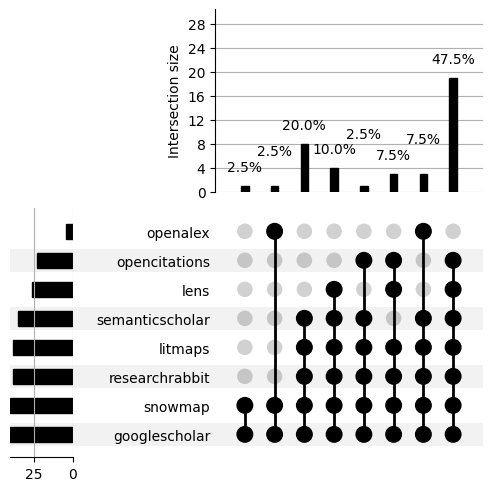

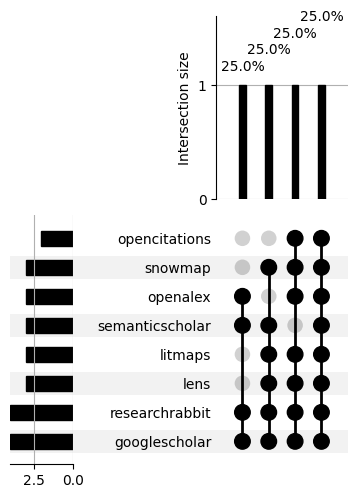

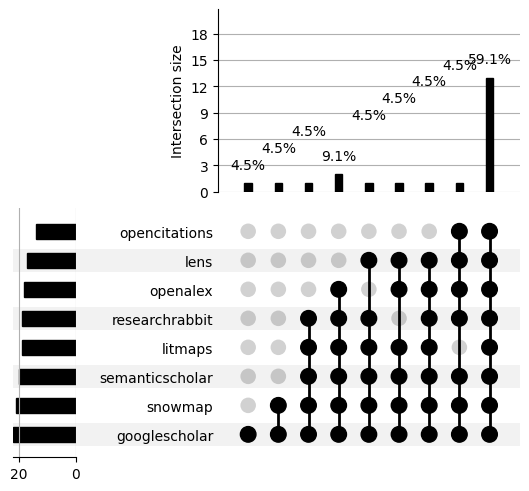

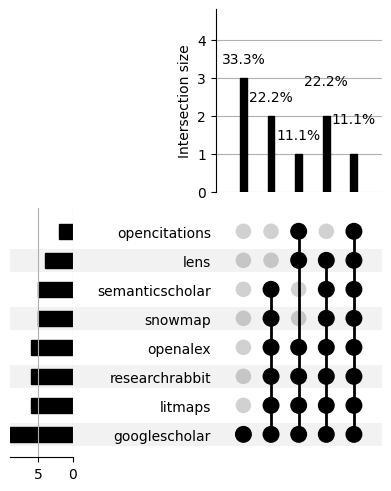

In [236]:
upset_from_global_presence(presence_slr1, "", "slr1_upset.png", figsize=(10, 5))
upset_from_global_presence(global_presence_slr2, "", "slr2_upset.png", figsize=(10, 5))
upset_from_global_presence(global_presence_slr3, "", "slr3_upset.png", figsize=(10, 5))
upset_from_global_presence(global_presence_slr4, "", "slr4_upset.png", figsize=(10, 5))

In [237]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

def combine_upset_images_2x2(
    img1, img2, img3, img4,
    titles=("(a) SLR1", "(b) SLR2", "(c) SLR3", "(d) SLR4"),
    out_png="upset_2x2.png"
):
    fig, axes = plt.subplots(2, 2, figsize=(16, 12))
    axes = axes.flatten()

    images = [img1, img2, img3, img4]

    for ax, img_path, title in zip(axes, images, titles):
        img = mpimg.imread(img_path)
        ax.imshow(img)

        ax.text(
            0.5, 0, title,
            transform=ax.transAxes,
            ha="center",
            va="top",
            fontsize=14
        )

        ax.axis("off")

    plt.tight_layout()
    plt.savefig(out_png, dpi=300, bbox_inches="tight")
    plt.show()

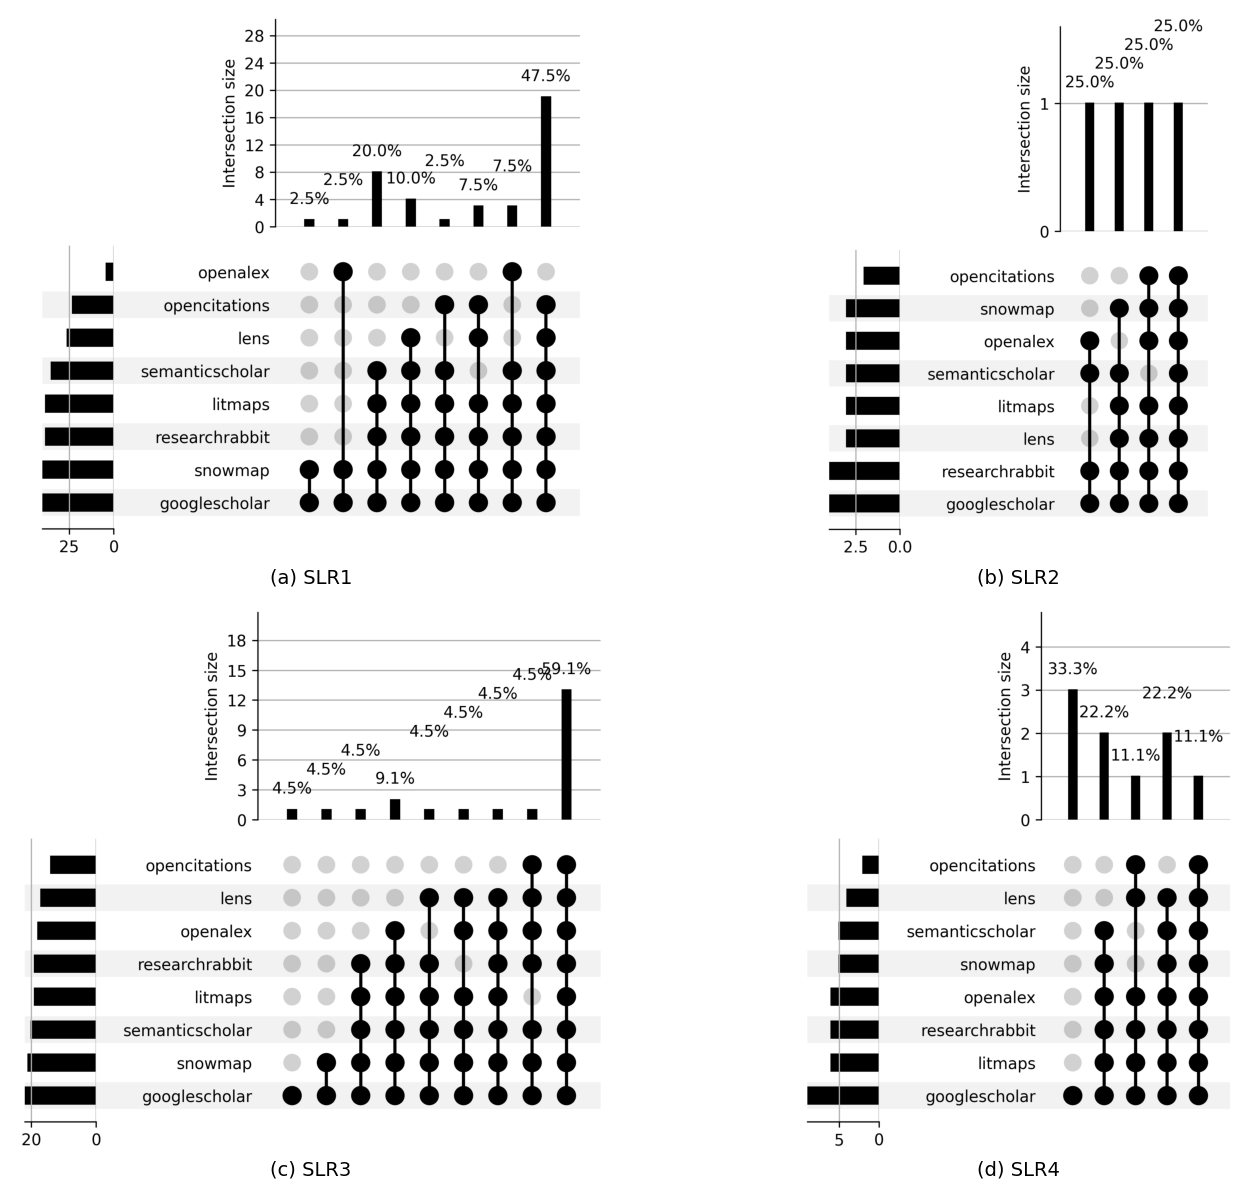

In [238]:
combine_upset_images_2x2(
    "slr1_upset.png",
    "slr2_upset.png",
    "slr3_upset.png",
    "slr4_upset.png",
    out_png="upset_all_slrs.png"
)

In [239]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import numpy as np

def crop_white_margins(img, tol=0.98):
    """
    Remove almost-white borders from an image.
    tol close to 1 means 'consider white' anything very bright.
    """
    if img.ndim == 3:
        gray = img[..., :3].mean(axis=2)
    else:
        gray = img

    mask = gray < tol
    coords = np.argwhere(mask)

    if coords.size == 0:
        return img

    y0, x0 = coords.min(axis=0)
    y1, x1 = coords.max(axis=0) + 1

    return img[y0:y1, x0:x1]


def combine_upset_images_2x2(
    img1, img2, img3, img4,
    titles=("(a) SLR1", "(b) SLR2", "(c) SLR3", "(d) SLR4"),
    out_png="upset_2x2.png",
    figsize=(35, 8),
    label_y=-0.10,
    hspace=0.05, # Decreased vertical space
    wspace=0, # Decreased horizontal space
    crop=True
):
    fig, axes = plt.subplots(1, 4, figsize=figsize)
    axes = axes.flatten()

    images = [img1, img2, img3, img4]

    for ax, img_path, title in zip(axes, images, titles):
        img = mpimg.imread(img_path)

        if crop:
            img = crop_white_margins(img, tol=0.98)

        ax.imshow(img)
        ax.axis("off")

        ax.text(
            0.5, 0, title,
            transform=ax.transAxes,
            ha="center",
            va="top",
            fontsize=12,
        )

    plt.subplots_adjust(
        left=0.03,
        right=0.97,
        top=0.97,
        bottom=0.05,
        hspace=hspace,
        wspace=wspace
    )

    plt.savefig(out_png, dpi=300, bbox_inches="tight", pad_inches=0.02)
    plt.show()

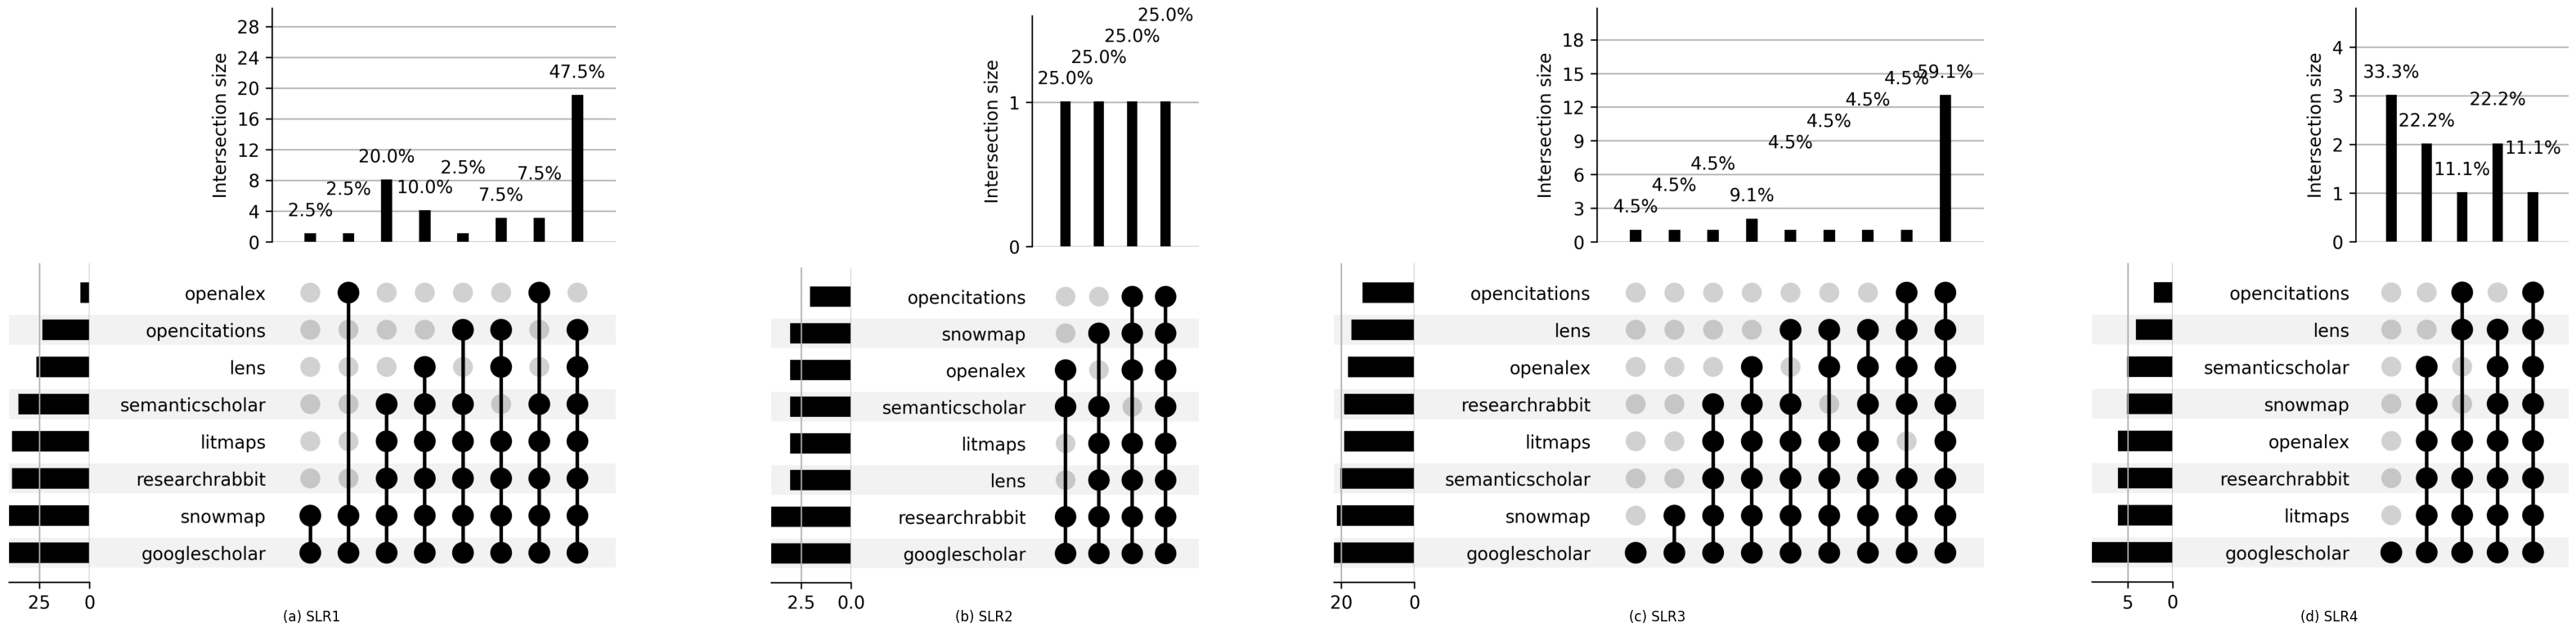

In [240]:
combine_upset_images_2x2(
    "slr1_upset.png",
    "slr2_upset.png",
    "slr3_upset.png",
    "slr4_upset.png",
    out_png="upset_all_slrs.png"
)

In [ ]:
import pandas as pd

pd.set_option('display.max_columns', None)
pd.set_option('display.width', 1000)
display(tabela)
ROOT_SLR2 = Path("../data/csvs_slr02/seed_studies02")
tabela_slr2 = run_slr02_with_duplicates(
    root_path=ROOT_SLR2,
    gt_df_for_metrics=gt_df_slr2,
    threshold=0.85
)
display(tabela_slr2)

ROOT_SLR3 = Path("../data/csvs_slr03/seed_studies03")
tabela_slr3 = run_slr02_with_duplicates(
    root_path=ROOT_SLR3,
    gt_df_for_metrics=gt_df_slr3,
    threshold=0.85
)
display(tabela_slr3)

ROOT_SLR4 = Path("../data/csvs_slr04/seed_studies04")
tabela_slr4 = run_slr02_with_duplicates(
    root_path=ROOT_SLR4,
    gt_df_for_metrics=gt_df_slr4,
    threshold=0.85
)
display(tabela_slr4)

,SLR,Ferramenta,TP,FP,FN,Recall,Included (%),Precision (%),F1 (%)
0,new_csvs_slr01,googlescholar,40,92,0,1.000,100.0,30.3,46.5
1,new_csvs_slr01,snowmap,40,106,0,1.000,100.0,27.4,43.0
2,new_csvs_slr01,researchrabbit,38,102,2,0.950,95.0,27.1,42.2
3,new_csvs_slr01,litmaps,38,111,2,0.950,95.0,25.5,40.2
4,new_csvs_slr01,semanticscholar,35,64,5,0.875,87.5,35.4,50.4
5,new_csvs_slr01,lens,26,67,14,0.650,65.0,28.0,39.1
6,new_csvs_slr01,opencitations,23,30,17,0.575,57.5,43.4,49.5
7,new_csvs_slr01,openalex,4,15,36,0.100,10.0,21.1,13.6


,SLR,Ferramenta,Included (%),TP,FP,FN,Precision (%),Recall (%),F1 (%),DOI matches,Title matches,GT size,Tool unique size
0,new_csvs_slr02,googlescholar,100.0,4,89,0,4.3,100.0,8.2,0,4,4,93
1,new_csvs_slr02,researchrabbit,100.0,4,83,0,4.6,100.0,8.8,0,4,4,87
2,new_csvs_slr02,litmaps,75.0,3,82,1,3.5,75.0,6.7,2,1,4,85
3,new_csvs_slr02,lens,75.0,3,70,1,4.1,75.0,7.8,2,1,4,73
4,new_csvs_slr02,openalex,75.0,3,72,1,4.0,75.0,7.6,3,0,4,75
5,new_csvs_slr02,semanticscholar,75.0,3,122,1,2.4,75.0,4.7,0,3,4,125
6,new_csvs_slr02,snowmap,75.0,3,82,1,3.5,75.0,6.7,2,1,4,85
7,new_csvs_slr02,opencitations,50.0,2,38,2,5.0,50.0,9.1,2,0,4,40


,SLR,Ferramenta,Included (%),TP,FP,FN,Precision (%),Recall (%),F1 (%),DOI matches,Title matches,GT size,Tool unique size
0,new_csvs_slr03,googlescholar,100.0,22,717,0,3.0,100.0,5.8,13,9,22,739
1,new_csvs_slr03,snowmap,95.5,21,581,1,3.5,95.5,6.7,16,5,22,602
2,new_csvs_slr03,semanticscholar,90.9,20,244,2,7.6,90.9,14.0,16,4,22,264
3,new_csvs_slr03,litmaps,90.9,20,637,2,3.0,90.9,5.9,16,4,22,657
4,new_csvs_slr03,researchrabbit,86.4,19,659,3,2.8,86.4,5.4,0,19,22,678
5,new_csvs_slr03,openalex,81.8,18,489,4,3.6,81.8,6.8,15,3,22,507
6,new_csvs_slr03,lens,77.3,17,365,5,4.5,77.3,8.4,15,2,22,382
7,new_csvs_slr03,opencitations,63.6,14,257,8,5.2,63.6,9.6,14,0,22,271


,SLR,Ferramenta,Included (%),TP,FP,FN,Precision (%),Recall (%),F1 (%),DOI matches,Title matches,GT size,Tool unique size
0,new_csvs_slr04,googlescholar,100.0,9,232,0,3.7,100.0,7.2,0,9,9,241
1,new_csvs_slr04,litmaps,66.7,6,131,3,4.4,66.7,8.2,5,1,9,137
2,new_csvs_slr04,openalex,66.7,6,125,3,4.6,66.7,8.6,5,1,9,131
3,new_csvs_slr04,researchrabbit,66.7,6,119,3,4.8,66.7,9.0,0,6,9,125
4,new_csvs_slr04,semanticscholar,55.6,5,132,4,3.6,55.6,6.8,0,5,9,137
5,new_csvs_slr04,snowmap,55.6,5,123,4,3.9,55.6,7.3,4,1,9,128
6,new_csvs_slr04,lens,44.4,4,90,5,4.3,44.4,7.8,3,1,9,94
7,new_csvs_slr04,opencitations,22.2,2,68,7,2.9,22.2,5.1,2,0,9,70


In [242]:
import pandas as pd

# Copio le tabelle già calcolate
summary_slr1 = tabela.copy()
summary_slr2 = tabela_slr2.copy()
summary_slr3 = tabela_slr3.copy()
summary_slr4 = tabela_slr4.copy()

# Rinomino le SLR in modo più leggibile
summary_slr1["SLR"] = "SLR1"
summary_slr2["SLR"] = "SLR2"
summary_slr3["SLR"] = "SLR3"
summary_slr4["SLR"] = "SLR4"

# Unisco tutto in un'unica tabella lunga
summary_all_slrs = pd.concat(
    [summary_slr1, summary_slr2, summary_slr3, summary_slr4],
    ignore_index=True
)

# Ordino per SLR e per Included (%)
summary_all_slrs = summary_all_slrs.sort_values(
    ["SLR", "Ferramenta", "Precision (%)", "Included (%)", "F1 (%)"],
    ascending=[True, False, False, False, False]
).reset_index(drop=True)

display(summary_all_slrs)

,SLR,Ferramenta,TP,FP,FN,Recall,Included (%),Precision (%),F1 (%),Recall (%),DOI matches,Title matches,GT size,Tool unique size
0,SLR1,snowmap,40,106,0,1.000,100.0,27.4,43.0,NaN,NaN,NaN,NaN,NaN
1,SLR1,semanticscholar,35,64,5,0.875,87.5,35.4,50.4,NaN,NaN,NaN,NaN,NaN
2,SLR1,researchrabbit,38,102,2,0.950,95.0,27.1,42.2,NaN,NaN,NaN,NaN,NaN
3,SLR1,opencitations,23,30,17,0.575,57.5,43.4,49.5,NaN,NaN,NaN,NaN,NaN
4,SLR1,openalex,4,15,36,0.100,10.0,21.1,13.6,NaN,NaN,NaN,NaN,NaN
5,SLR1,litmaps,38,111,2,0.950,95.0,25.5,40.2,NaN,NaN,NaN,NaN,NaN
6,SLR1,lens,26,67,14,0.650,65.0,28.0,39.1,NaN,NaN,NaN,NaN,NaN
7,SLR1,googlescholar,40,92,0,1.000,100.0,30.3,46.5,NaN,NaN,NaN,NaN,NaN
8,SLR2,snowmap,3,82,1,NaN,75.0,3.5,6.7,75.0,2.0,1.0,4.0,85.0
9,SLR2,semanticscholar,3,122,1,NaN,75.0,2.4,4.7,75.0,0.0,3.0,4.0,125.0


In [243]:
summary_pivot = summary_all_slrs.pivot_table(
    index="Ferramenta",
    columns="SLR",
    values="Included (%)",
    aggfunc="first"
).reset_index()

summary_pivot = summary_pivot.sort_values("Ferramenta").reset_index(drop=True)

display(summary_pivot)

SLR,Ferramenta,SLR1,SLR2,SLR3,SLR4
0,googlescholar,100.0,100.0,100.0,100.0
1,lens,65.0,75.0,77.3,44.4
2,litmaps,95.0,75.0,90.9,66.7
3,openalex,10.0,75.0,81.8,66.7
4,opencitations,57.5,50.0,63.6,22.2
5,researchrabbit,95.0,100.0,86.4,66.7
6,semanticscholar,87.5,75.0,90.9,55.6
7,snowmap,100.0,75.0,95.5,55.6


In [244]:
pivot_precision = summary_all_slrs.pivot_table(
    index="Ferramenta",
    columns="SLR",
    values="Precision (%)",
    aggfunc="first"
).reset_index()
pivot_precision = pivot_precision.sort_values("Ferramenta").reset_index(drop=True)
display(pivot_precision)

SLR,Ferramenta,SLR1,SLR2,SLR3,SLR4
0,googlescholar,30.3,4.3,3.0,3.7
1,lens,28.0,4.1,4.5,4.3
2,litmaps,25.5,3.5,3.0,4.4
3,openalex,21.1,4.0,3.6,4.6
4,opencitations,43.4,5.0,5.2,2.9
5,researchrabbit,27.1,4.6,2.8,4.8
6,semanticscholar,35.4,2.4,7.6,3.6
7,snowmap,27.4,3.5,3.5,3.9


In [245]:
pivot_f1 = summary_all_slrs.pivot_table(
    index="Ferramenta",
    columns="SLR",
    values="F1 (%)",
    aggfunc="first"
).reset_index()

display(pivot_f1)

SLR,Ferramenta,SLR1,SLR2,SLR3,SLR4
0,googlescholar,46.5,8.2,5.8,7.2
1,lens,39.1,7.8,8.4,7.8
2,litmaps,40.2,6.7,5.9,8.2
3,openalex,13.6,7.6,6.8,8.6
4,opencitations,49.5,9.1,9.6,5.1
5,researchrabbit,42.2,8.8,5.4,9.0
6,semanticscholar,50.4,4.7,14.0,6.8
7,snowmap,43.0,6.7,6.7,7.3
